# Signal and per-trial spike correlation in simultaneously recorded selective pairs

## Introduction

A single neuron's firing rate says what that neuron encodes. It says nothing
about whether neurons act together — and coordinated activity between neurons
carries information that neither carries alone, gates what downstream targets
receive, and changes with behavioural state even when firing rates do not.

Two neurons recorded at the same time can be related in two distinct ways, and
conflating them is the standard error in this literature.

**Signal correlation** is similarity of *tuning*. If two neurons both respond to
fixation onset with the same time course, their trial-averaged responses
resemble each other. This is a statement about what the two neurons encode, and
it survives averaging: it is visible in the mean response and requires no
simultaneous recording in principle.

**Per-trial spike correlation** is trial-by-trial *co-firing*. If, within the
same fixation, one neuron's spikes fall at a reliable delay from the other's,
beyond what their average rate profiles predict, the two are coupled in time.
This requires simultaneous recording by definition, and averaging destroys it.

### A note on the name

This second measure is conventionally called *noise correlation*, and that name
is avoided here deliberately. Classical noise correlation is a single number per
pair: the Pearson correlation, across trials, of the two neurons' spike **counts**
in a window, after each neuron's condition mean has been subtracted. What is
computed here is a full cross-correlogram of the two spike trains **within each
fixation**, averaged across fixations afterwards. The two differ in what they can
see and in what scale they live on:

| | classical noise correlation | per-trial spike correlation (here) |
|---|---|---|
| unit of observation | one spike count per trial | one 1 ms spike train per trial |
| resolves timing | no — a window is integrated away | yes — a value at every lag |
| range | [−1, 1], normalised | unnormalised counts of spike pairs |
| what a null must destroy | trial-to-trial count covariation | fine temporal alignment |

Reporting the second under the first's name would invite comparing magnitudes
with a literature that measured something else. Everything below therefore says
*per-trial spike correlation*, and *trial* means one fixation.

### Why the distinction matters

The two measures are formally independent. Two neurons can have identical mean
responses and be statistically independent trial to trial; two neurons with
unrelated tuning can co-fire tightly through shared input. Which of the two a
behavioural variable modulates is therefore a substantive question, not a
technicality — modulating shared tuning means the population's *representation*
changes, while modulating co-firing means its *correlation structure* changes,
and these have opposite consequences for how much information the population
carries.

This chapter asks which of the two, if either, distinguishes **interactive-face**
fixations from non-interactive-face and object fixations, in each of four
regions — BLA, ACCg, dmPFC and OFC — and across the region pairs the recordings
support.

### What is asked

1. Is there signal correlation between simultaneously recorded selective pairs,
   beyond what any two units of the same region show?
2. Does it depend on the fixation condition?
3. Is there per-trial spike correlation beyond what each unit's own
   fixation-locked rate profile predicts?
4. Does *that* depend on the fixation condition?
5. Are the two related — do pairs with shared tuning also co-fire?
6. Does any of this extend across regions?

## Methods

### Recordings, units and pairs

Single units were recorded simultaneously from BLA, ACCg, dmPFC and OFC while
two macaques viewed each other and non-social objects. Analysis is restricted to
**FDR-corrected selective units** — units significantly selective for at least
one fixation-condition contrast in the single-unit analysis
(`three_condition_core` family, `is_selective_unit_corrected`). Two
justifications: a unit with no reliable fixation response contributes a mean
timeline that is mostly estimation noise, and correlating noise with noise adds
variance and nothing else; and the question *do units that respond to fixation
condition share response structure* presupposes units that respond.

A **pair** is two selective units recorded in the same session. Both measures are
defined on the same pairs, so they can be compared pair for pair. Pair counts
grow with the square of the simultaneously recorded units, so a session with 20
units contributes 190 within-region pairs and a session with 5 contributes 10;
the counts reported below are therefore dominated by a minority of dense
sessions, which is why the per-session distribution is given as a median and a
maximum rather than a mean.

### Fixation conditions

Three conditions throughout, matching the single-unit and population analyses so
results can be joined without translation:

- **interactive face** — face fixations during interactive periods
- **non-interactive face** — face fixations outside them
- **object** — object fixations, pooled across interactive state

### Analysis window

All correlations use spikes within $[-500, +500]$ ms of fixation onset. The
per-trial measure uses 1 ms bins, **unsmoothed** ($N = 1000$ bins); the signal
measure uses the 10 ms binned rates ($M = 100$ bins) produced by the same
extraction, so the fixations, units and trials are identical to those in every
other chapter. Smoothing before cross-correlation blurs exactly the fine timing
the per-trial measure exists to detect.

The window is not widened. 95% of $\pm 5$ s surrounds of an analysed fixation
contain at least one *other* analysed fixation (median 5), so data outside the
window is not neutral baseline and a shifted-window null would compare against a
different behavioural condition rather than against nothing.

---

### Per-trial spike correlation

Write $x_i^{(t)} \in \{0,1,2,\dots\}^N$ and $x_j^{(t)}$ for the 1 ms binned spike
trains of units $i$ and $j$ on fixation $t$, with $t = 1,\dots,T_c$ the fixations
of condition $c$.

**The statistic.** The **linear** cross-correlation of one fixation's two trains,

$$
r_{ij}^{(t)}(\ell) \;=\; \sum_{n} x_i^{(t)}[n]\, x_j^{(t)}[n+\ell],
\qquad \ell = -(N-1),\dots,N-1 ,
$$

with terms outside $[1, N]$ absent. At lag $\ell$ only the $N - |\ell|$ genuinely
overlapping bins contribute, so no spike is ever paired with one a full window
away. In words, $r_{ij}^{(t)}(\ell)$ counts the spike pairs separated by exactly
$\ell$ ms within that fixation.

It is evaluated by zero-padding both trains to length $M \ge 2N-1$ and using the
transform,

$$
r_{ij}^{(t)} \;=\; \mathcal{F}^{-1}\!\left\{\overline{\mathcal{F}(x_i^{(t)})}\;\cdot\;\mathcal{F}(x_j^{(t)})\right\},
$$

which is exact, not an approximation. **The padding is what makes this linear.**
An unpadded transform returns the *circular* correlation
$\sum_n x_i[n]\,x_j[(n+\ell) \bmod N]$, which pairs a spike at $-500$ ms with one
at $+500$ ms and reports the pair at a short lag. The three are related exactly by

$$
r^{\text{circ}}(\ell) \;=\; r^{\text{lin}}(\ell) + r^{\text{lin}}(\ell - N) + r^{\text{lin}}(\ell + N),
$$

so the difference is aliasing, not truncation. This analysis uses the linear form
throughout, matching `scipy.signal.correlate(..., mode="full")` and the
behavioural cross-correlations elsewhere in this thesis.

Averaging over the fixations of a condition gives the pair's observed correlogram:

$$
R_{ij}^{c}(\ell) \;=\; \frac{1}{T_c}\sum_{t=1}^{T_c} r_{ij}^{(t)}(\ell).
$$

**The null: circular shift.** For draw $d = 1,\dots,D$ with $D = 50$, every
fixation independently receives its own rotation $s^{(t,d)}$ drawn uniformly from
the offsets with $|s| \ge 50$ ms:

$$
\tilde{x}_j^{(t,d)}[n] \;=\; x_j^{(t)}\!\left[(n - s^{(t,d)}) \bmod N\right],
\qquad
R_{ij}^{c,d}(\ell) \;=\; \frac{1}{T_c}\sum_{t} \big(x_i^{(t)} \star \tilde{x}_j^{(t,d)}\big)(\ell),
$$

and the null is summarised by its mean and spread across draws:

$$
\mu_{ij}^{c}(\ell) = \frac{1}{D}\sum_{d} R_{ij}^{c,d}(\ell),
\qquad
\sigma_{ij}^{c}(\ell) = \operatorname{sd}_{d}\big[R_{ij}^{c,d}(\ell)\big].
$$

The rotation is applied **within each fixation**, which is the whole point: every
fixation keeps its own spike count and its own slow envelope, so two neurons
whose excitability merely rises and falls together across fixations produce no
excess against this null. Only fine temporal alignment is destroyed. The $50$ ms
floor stops a rotation shorter than the coordination timescale from leaving the
effect partly intact.

**Excess and z.** Everything reported is the null-corrected quantity

$$
E_{ij}^{c}(\ell) \;=\; R_{ij}^{c}(\ell) - \mu_{ij}^{c}(\ell),
\qquad
z_{ij}^{c}(\ell) \;=\; \frac{E_{ij}^{c}(\ell)}{\sigma_{ij}^{c}(\ell)} .
$$

The linear correlation tapers — fewer bins contribute as $|\ell|$ grows — but both
the observed value and the null carry the identical taper, so it cancels in
$E$ and in $z$.

**Scalar summaries.** A correlogram is reduced to one number by averaging over a
lag window of half-width $W$ — the excess and the $z$ trace each in their own
right, the average taken over lags rather than the ratio of two averages:

$$
\bar{E}_{ij}^{c}(W) = \frac{1}{|\mathcal{L}_W|} \sum_{\ell \in \mathcal{L}_W} E_{ij}^{c}(\ell),
\qquad
\bar{z}_{ij}^{c}(W) = \frac{1}{|\mathcal{L}_W|} \sum_{\ell \in \mathcal{L}_W} z_{ij}^{c}(\ell),
\qquad \mathcal{L}_W = \{\ell : |\ell| \le W\}.
$$

Only $|\ell| \le 250$ ms of each correlogram is stored, which sets the widest
window available. That is not a limitation in practice: every peak in this data
returns to baseline well before 250 ms, and the overlap taper makes the far lags
progressively noisier — at $\ell = 900$ ms only 100 of the 1000 bins contribute.

Two windows are used, for two different questions.
$W = 250$ ms is the chapter's reporting window, chosen to match the signal
correlation's so the two are read on the same span of lags; it answers *how much
excess co-firing does this condition carry in total*.
$W = 10$ ms is used **only** for whether one individual pair is coordinated,
because a monosynaptic or common-input peak lives inside $\pm 10$ ms and
averaging $z$ over half a second of empty lags dilutes it to nothing — run at
$W = 250$ ms, zero pairs are individually significant anywhere, which is a
statement about the window rather than about the pairs.

**Trial-count matching.** Interactive-face fixations outnumber the others roughly
six to one, and $\bar{E}$ is estimated more precisely from more fixations, so an
unmatched condition contrast is partly a contrast of sample sizes. Every pair is
therefore recomputed end to end at a common count
$T^{\star} = \min_{c} T_{c}$ within its session, with the fixations subsampled at
random, and **every condition contrast in this chapter uses the matched column.**
The unmatched column is used only where no condition is compared against another.

**Artifact removal.** Two randomly sampled neurons are essentially never
monosynaptically connected, so a sharp zero-lag peak shared by most pairs on a
recording day reflects common input — movement, arousal, or a shared reference —
rather than a pairwise interaction. Its signature is that it is a property of the
*day and array*, not of the pair. For each date $d$, let $p_d$ be the fraction of
that day's pairs with a zero-lag $z$ above 3; a date is dropped when

$$
\frac{p_d - \operatorname{med}(p)}{\max\!\big(1.4826 \cdot \operatorname{MAD}(p),\; 0.02\big)} \;>\; 3.5 .
$$

The floor on the scale is not cosmetic. When the artifact hits one day and every
other day is clean, $\operatorname{MAD}(p)$ is exactly zero and an unfloored score
is undefined **precisely in the case the rule exists to catch**. Flagged dates are
removed from every result rather than annotated, because a day-level contaminant
cannot be corrected pair by pair.

---

### Signal correlation

**The statistic.** For each pair and condition, the condition-averaged rate
timelines in 10 ms bins,

$$
\bar{f}_i^{\,c}[m] \;=\; \frac{1}{T_c}\sum_{t} f_i^{(t)}[m], \qquad m = 1,\dots,M,
$$

are cross-correlated with a **normalised** estimator evaluated on the overlapping
samples at each lag. With $O_\ell$ the overlap and $\mu_{i,\ell}, \mu_{j,\ell}$ the
means taken within it,

$$
\rho_{ij}^{c}(\ell) \;=\;
\frac{\sum_{m \in O_\ell}\big(\bar{f}_i^{\,c}[m+\ell]-\mu_{i,\ell}\big)\big(\bar{f}_j^{\,c}[m]-\mu_{j,\ell}\big)}
{\sqrt{\sum_{m \in O_\ell}\big(\bar{f}_i^{\,c}[m+\ell]-\mu_{i,\ell}\big)^{2}}\;
 \sqrt{\sum_{m \in O_\ell}\big(\bar{f}_j^{\,c}[m]-\mu_{j,\ell}\big)^{2}}} .
$$

Re-centring **within the overlap** is what keeps this a genuine Pearson
coefficient bounded in $[-1,1]$ at every lag, rather than a dot product that grows
with firing rate. A positive lag means unit $i$ follows unit $j$.

**The null: cross-session pairing.** Every unit is fixation-locked, so any two
mean timelines correlate before shared tuning is involved, and a null that merely
scrambled time would confirm that trivial structure rather than control for it.
Instead unit $i$ is correlated against $K = 20$ units of the **same region
recorded on different sessions** — fixation-locked, real, and through the same
pipeline, but sharing no session, no array and no behaviour:

$$
\rho_{ij}^{c,\text{null}}(\ell) \;=\; \frac{1}{K}\sum_{k=1}^{K} \rho_{ik}^{c}(\ell),
\qquad
\Delta_{ij}^{c}(\ell) \;=\; \rho_{ij}^{c}(\ell) - \rho_{ij}^{c,\text{null}}(\ell).
$$

**Summarising.** $\Delta$ is reported as its mean over $|\ell| \le 250$ ms, the same
window as the per-trial measure. Two alternatives were tried and rejected.
Taking each *pair's* maximum inflates the level — every pair peaks at a different
lag, so the mean of the maxima far exceeds the maximum of the mean, and bars
built that way read $\approx 0.30$ beside traces peaking at $\approx 0.10$.
Reading every pair at a single group-level peak lag is unbiased but makes the
summary depend on where one group's mean happened to peak. The windowed mean
selects nothing and lands below the peak by construction, which is the honest
cost of not selecting.

---

### Statistics

**Condition contrasts are paired within pair.** Every pair contributes all three
conditions: the same two neurons, the same electrodes, the same session,
differing only in which fixations were used. That removes pair identity, firing
rate and recording quality in one step, which an unpaired comparison across
separate pair populations could not do. A two-sided Wilcoxon signed-rank test is
applied to the within-pair difference, and p-values are Benjamini–Hochberg
corrected across the contrasts reported in a figure.

**Effect sizes are interpreted; p-values are not.** With thousands of pairs per
region almost any difference reaches significance — a mean difference of
$4 \times 10^{-5}$ does. The matched-pairs rank-biserial correlation is reported
throughout,

$$
r_{\text{rb}} \;=\; \frac{n_{+} - n_{-}}{n_{+} + n_{-}},
$$

with $n_{+}$ and $n_{-}$ the numbers of pairs favouring each condition. It is the
proportion of pairs favouring one condition minus the proportion favouring the
other, so $r_{\text{rb}} = 0.05$ means roughly 52.5% against 47.5% — a coin that
is barely bent, however small the p-value beside it.

**Is a group above its null at all** is a one-sample Wilcoxon signed-rank test of
the per-pair $\bar{E}$ against zero, zero being the null's own expectation.

**Is one pair above its null** is a separate question, answered by converting
that pair's $\bar{z}_{ij}^{c}(10\text{ ms})$ to a one-sided p-value
$p_{ij} = 1 - \Phi(\bar{z}_{ij}^{c})$ and applying Benjamini–Hochberg **across the
pairs within each group**. The normal
approximation is the weak step — the null spread comes from 50 draws, so the
statistic is t-like and the tail is slightly heavier than assumed — which makes
these counts mildly optimistic. No claim in this chapter rests on them; they are
reported because the contrast between a population that is clearly above null and
individual pairs that mostly are not is itself the finding.

**Relating the two measures** is a Spearman rank correlation, across pairs within
each region and condition, between each pair's $\bar{E}$ (per-trial, $\pm 250$ ms)
and its $\Delta$ (signal, $\pm 250$ ms). Spearman rather than Pearson because
neither distribution is symmetric and the per-trial excess is bounded below by
its null.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.analysis import fixation_signal_correlation as sc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_correlation_overview as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CFG_PATH = str(repo_root / "configs" / "dataset.yaml")
cfg = load_config(CFG_PATH)
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "overview"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairOverviewPlotSettings(output_dir=FIGURE_DIR)
SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"

# Condition comparisons run on the trial-count-matched column throughout:
# interactive-face fixations outnumber the others roughly six to one, and an
# excess estimated from more fixations is estimated more precisely, so an
# unmatched contrast is partly a contrast of sample sizes.
SPIKE_METRIC = psc.MATCHED_WINDOW_METRIC
print("figures ->", FIGURE_DIR)
print("spike-correlation metric:", SPIKE_METRIC)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/overview
spike-correlation metric: circular_shift_mean_excess_pm250ms_matched


### Figure 1 — What the two measures are

Both paths start from the same trials and diverge at one step: whether the
trials are averaged before correlating or after. Averaging first is what removes
trial-by-trial co-firing, which is why the left-hand path can be computed on
units that were never recorded together and the right-hand path cannot.

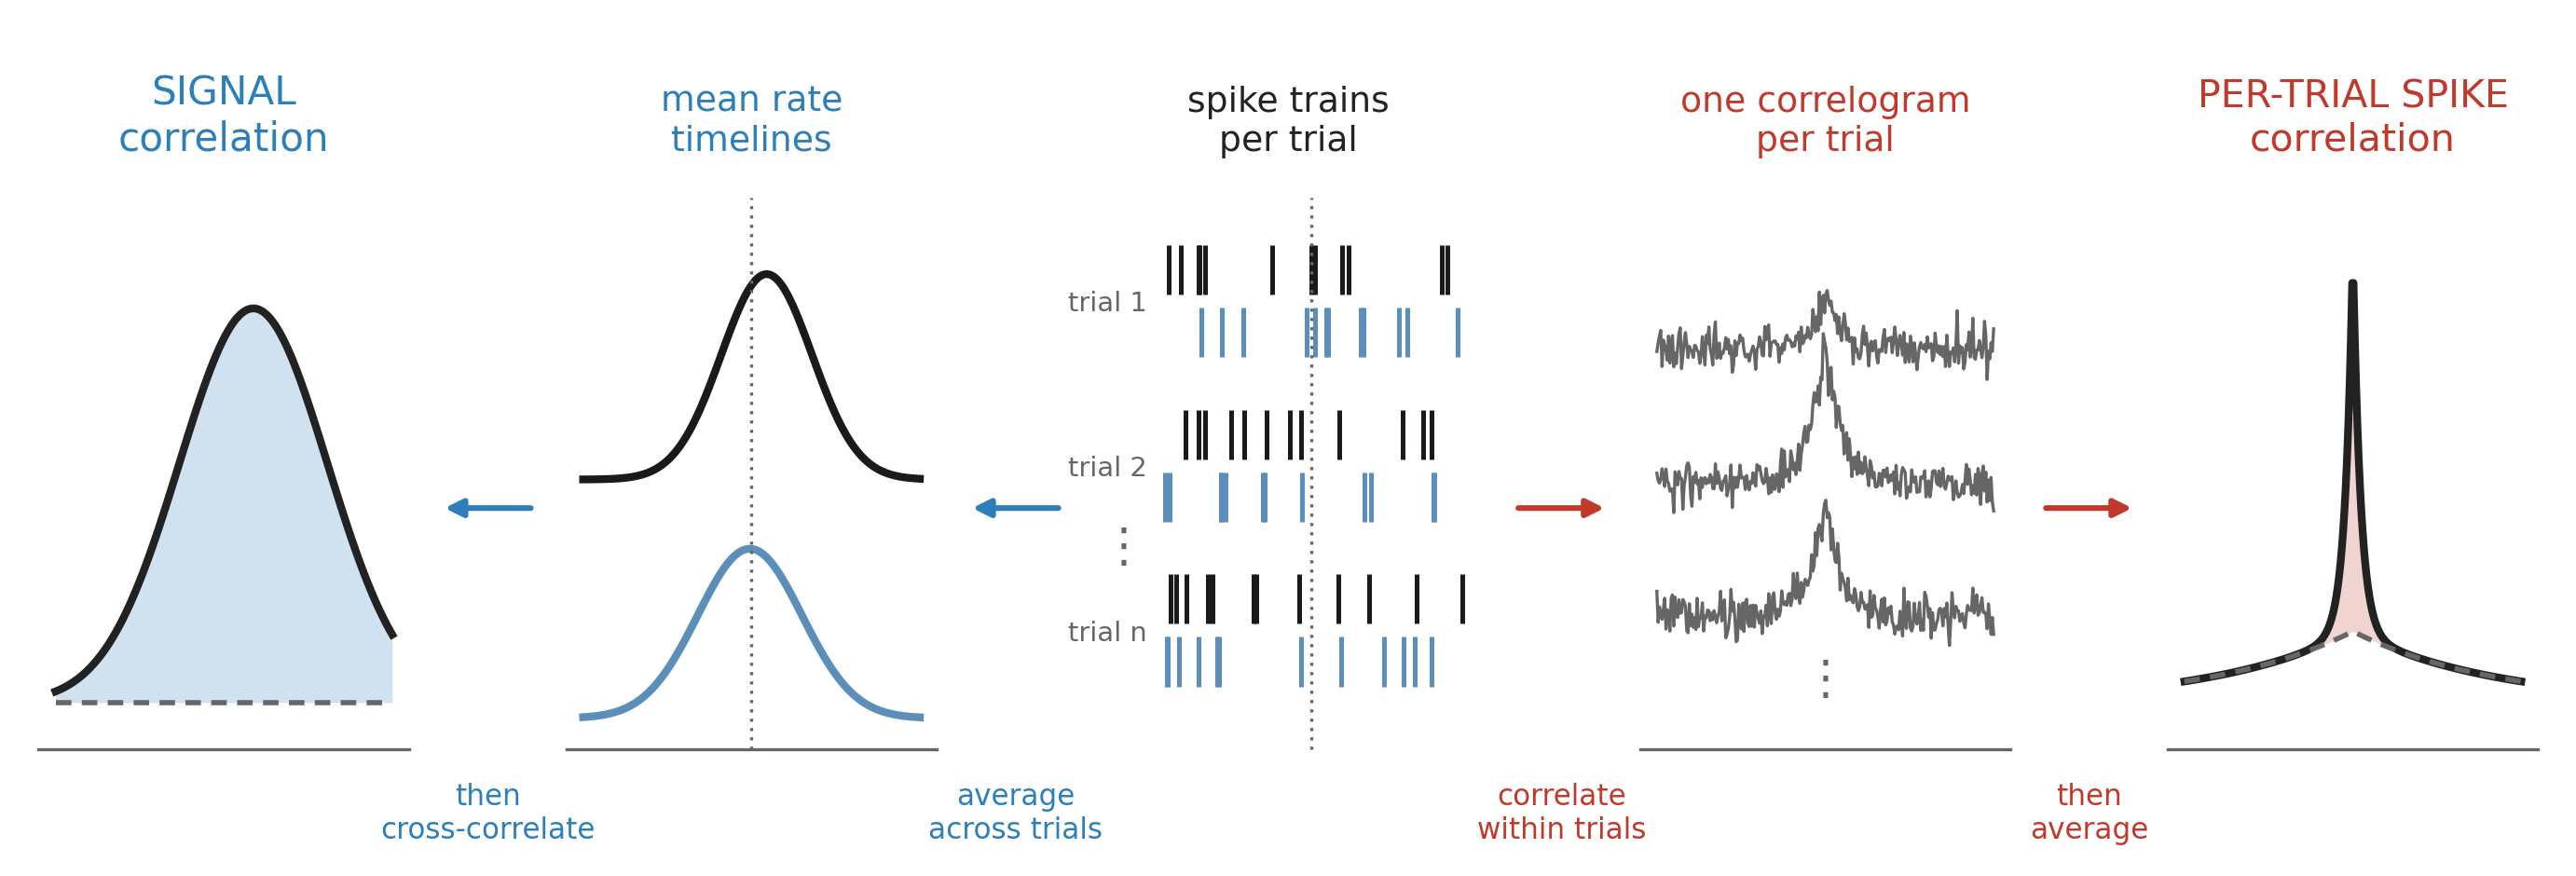

In [2]:
fig, paths = viz.plot_method_schematic(figs)
display(Image(filename=str(paths["png"])))

## Results

### What the analysis is built from

The tables and figure below are the chapter's denominators: how many selective
units contribute a pair, over how many recording days and sessions, how many
pairs each group supplies, and how many of those pairs are individually above
the circular-shift null.

In [3]:
# --- per-trial spike correlation: per-fixation trains, circular-shift null ---
spikes = psc.load_pair_coordination(CFG_PATH)[0]
spikes, dropped = psc.drop_zero_lag_artifact_dates(spikes)
spikes = spikes.loc[spikes["both_selective"]].copy()
spikes["scope"] = np.where(spikes["same_region"], "within_region", "cross_region")
spike_traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
print(f"spike correlation: {len(spikes):,} pair-conditions, both units FDR-selective   "
      f"(artifact dates removed: {dropped})")

# --- signal correlation: condition-averaged timelines, cross-session null ----
signal_settings = sc.SignalCorrelationSettings(cfg_path=CFG_PATH)
units, timeline = sc.load_condition_timelines(signal_settings)
signal, signal_lags = sc.build_pair_correlations(units, timeline, signal_settings)
signal_traces = {
    "lags_ms": signal_lags,
    "traces": sc.build_group_traces(signal, signal_settings),
}
print(f"signal: {len(signal):,} pairs from {len(units)} FDR-selective units")

joined = sc.join_with_spike_correlation(
    signal, signal_settings, signal_metric=sc.WINDOW_METRIC,
    spike_metric=psc.WINDOW_METRIC,
)
correlations = sc.correlate_signal_with_spike_correlation(joined)

spike correlation: 113,163 pair-conditions, both units FDR-selective   (artifact dates removed: ['01172019', '09272018', '09292018'])


signal: 5,206 pairs from 574 FDR-selective units


#### Figure 2 — Units, pairs and individually significant pairs

The third panel is the one that changes how the rest reads. Every group's
*population* of pairs sits above its null, but only a small percentage of
*individual* pairs does. The effect is a broad shift, not a coupled subset.

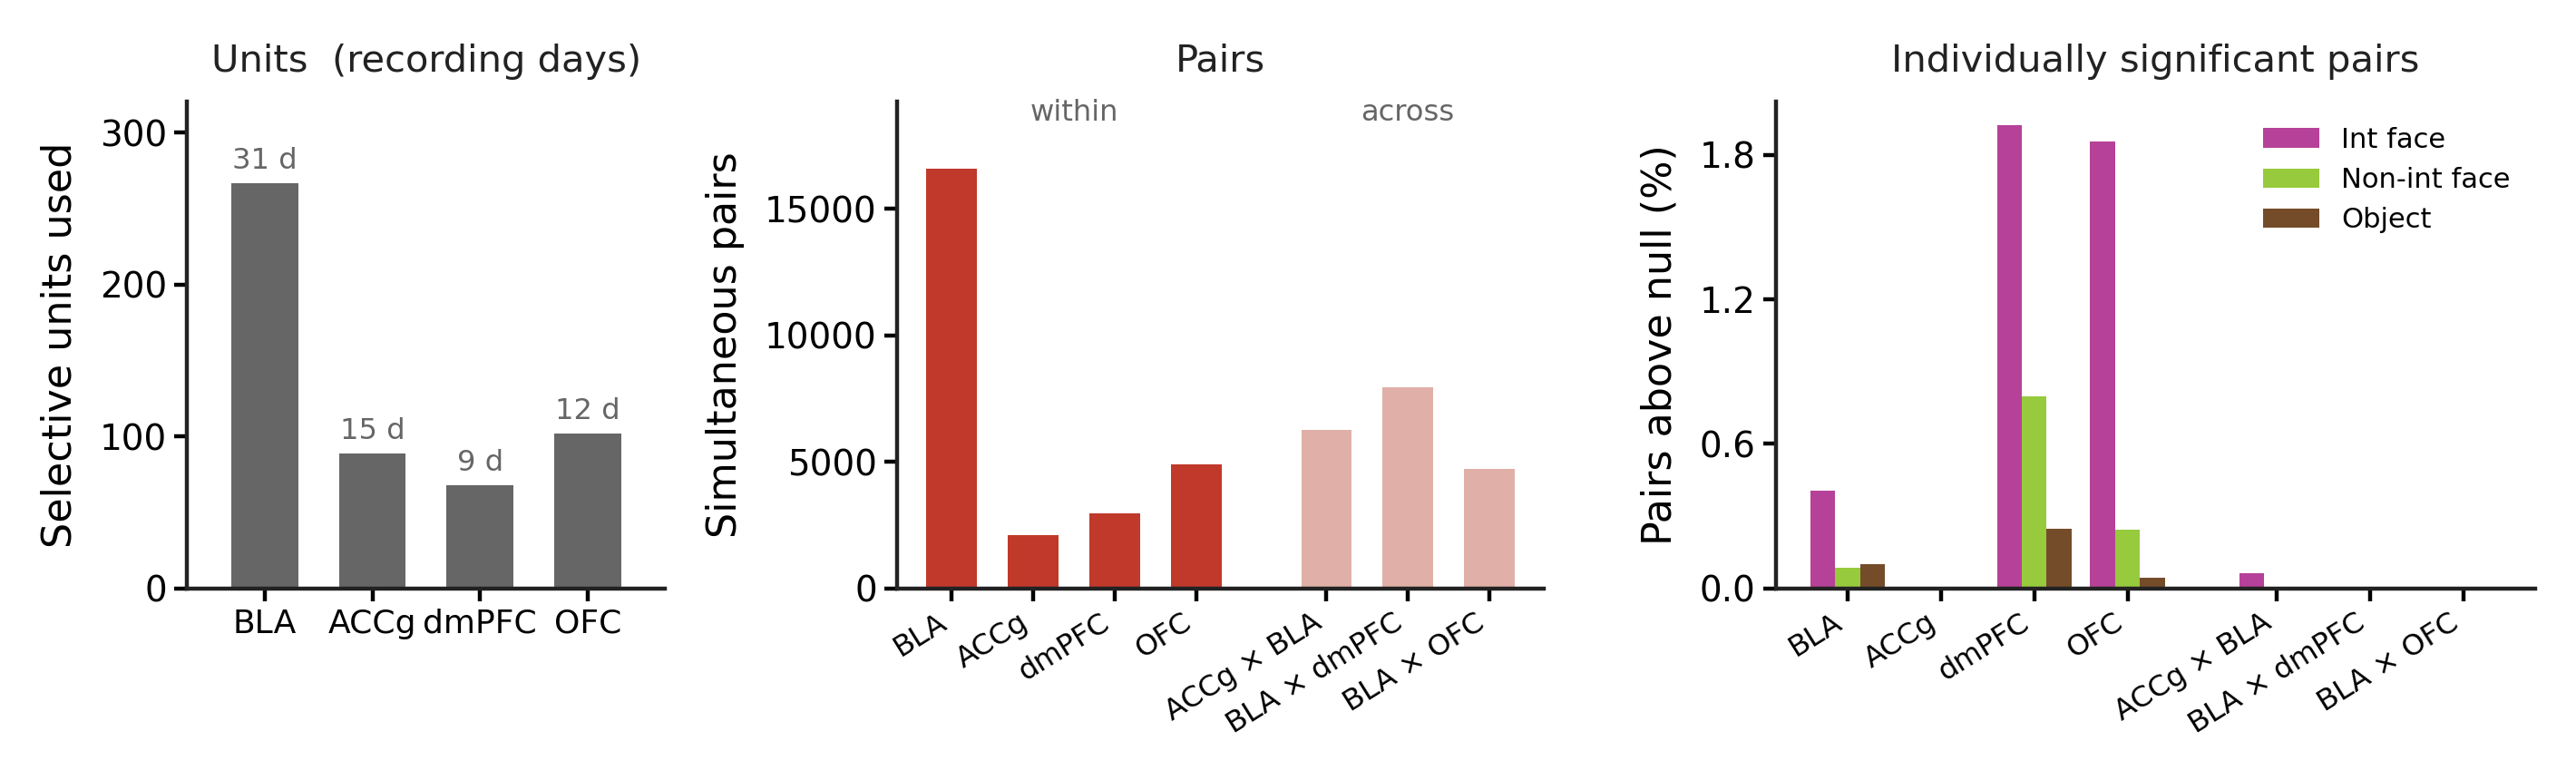

**Units, sessions and pairs behind each reported group**

,scope,region_pair,n_units,n_dates,n_sessions,n_pairs,median_pairs_per_session,max_pairs_per_session,median_n_fixations
0,cross_region,bla-dmpfc,235,14,140,7944,32.0,300,116.0
1,cross_region,accg-bla,194,12,115,6254,39.0,231,105.0
2,cross_region,bla-ofc,141,11,107,4714,25.0,119,80.0
3,cross_region,accg-dmpfc,37,6,58,334,5.5,18,101.5
4,within_region,bla,267,31,307,16582,15.0,528,120.0
5,within_region,ofc,102,12,120,4906,21.0,136,77.0
6,within_region,dmpfc,68,9,83,2949,10.0,105,106.0
7,within_region,accg,89,15,144,2117,10.0,78,51.0


**Pairs individually above the circular-shift null (FDR across pairs)**

,scope,region_pair,condition,n_pairs,n_significant,frac_significant,median_z
0,cross_region,accg-bla,face_interactive,6206,4,0.00064,-0.00260
1,cross_region,accg-bla,face_non_interactive,4049,0,0.00000,-0.02030
2,cross_region,accg-bla,object,5152,0,0.00000,0.00000
3,cross_region,accg-dmpfc,face_interactive,324,0,0.00000,0.00271
4,cross_region,accg-dmpfc,face_non_interactive,178,0,0.00000,-0.04700
5,cross_region,accg-dmpfc,object,228,0,0.00000,-0.03417
6,cross_region,bla-dmpfc,face_interactive,7874,0,0.00000,0.02266
7,cross_region,bla-dmpfc,face_non_interactive,5568,0,0.00000,-0.01402
8,cross_region,bla-dmpfc,object,5867,0,0.00000,-0.01069
9,cross_region,bla-ofc,face_interactive,4711,0,0.00000,0.00257


In [4]:
counts = psc.build_recording_counts(spikes)
significant = psc.count_significant_pairs(spikes)

fig, paths = viz.plot_recording_inventory(counts, significant, figs)
display(Image(filename=str(paths["png"])))

display(Markdown("**Units, sessions and pairs behind each reported group**"))
display(
    counts.loc[:, ["scope", "region_pair", "n_units", "n_dates", "n_sessions", "n_pairs",
                   "median_pairs_per_session", "max_pairs_per_session",
                   "median_n_fixations"]]
)

display(Markdown("**Pairs individually above the circular-shift null (FDR across pairs)**"))
display(
    significant.loc[:, ["scope", "region_pair", "condition", "n_pairs",
                        "n_significant", "frac_significant", "median_z"]].round(5)
)

### Within region

#### Figure 3 — Signal correlation

The cross-session null is subtracted, so zero means "resembles a same-region
unit from another session no more than chance". Interactive face is above the
other two conditions in every region, but only in BLA and OFC does the difference
survive correction, and in OFC it is several times larger than anywhere else.

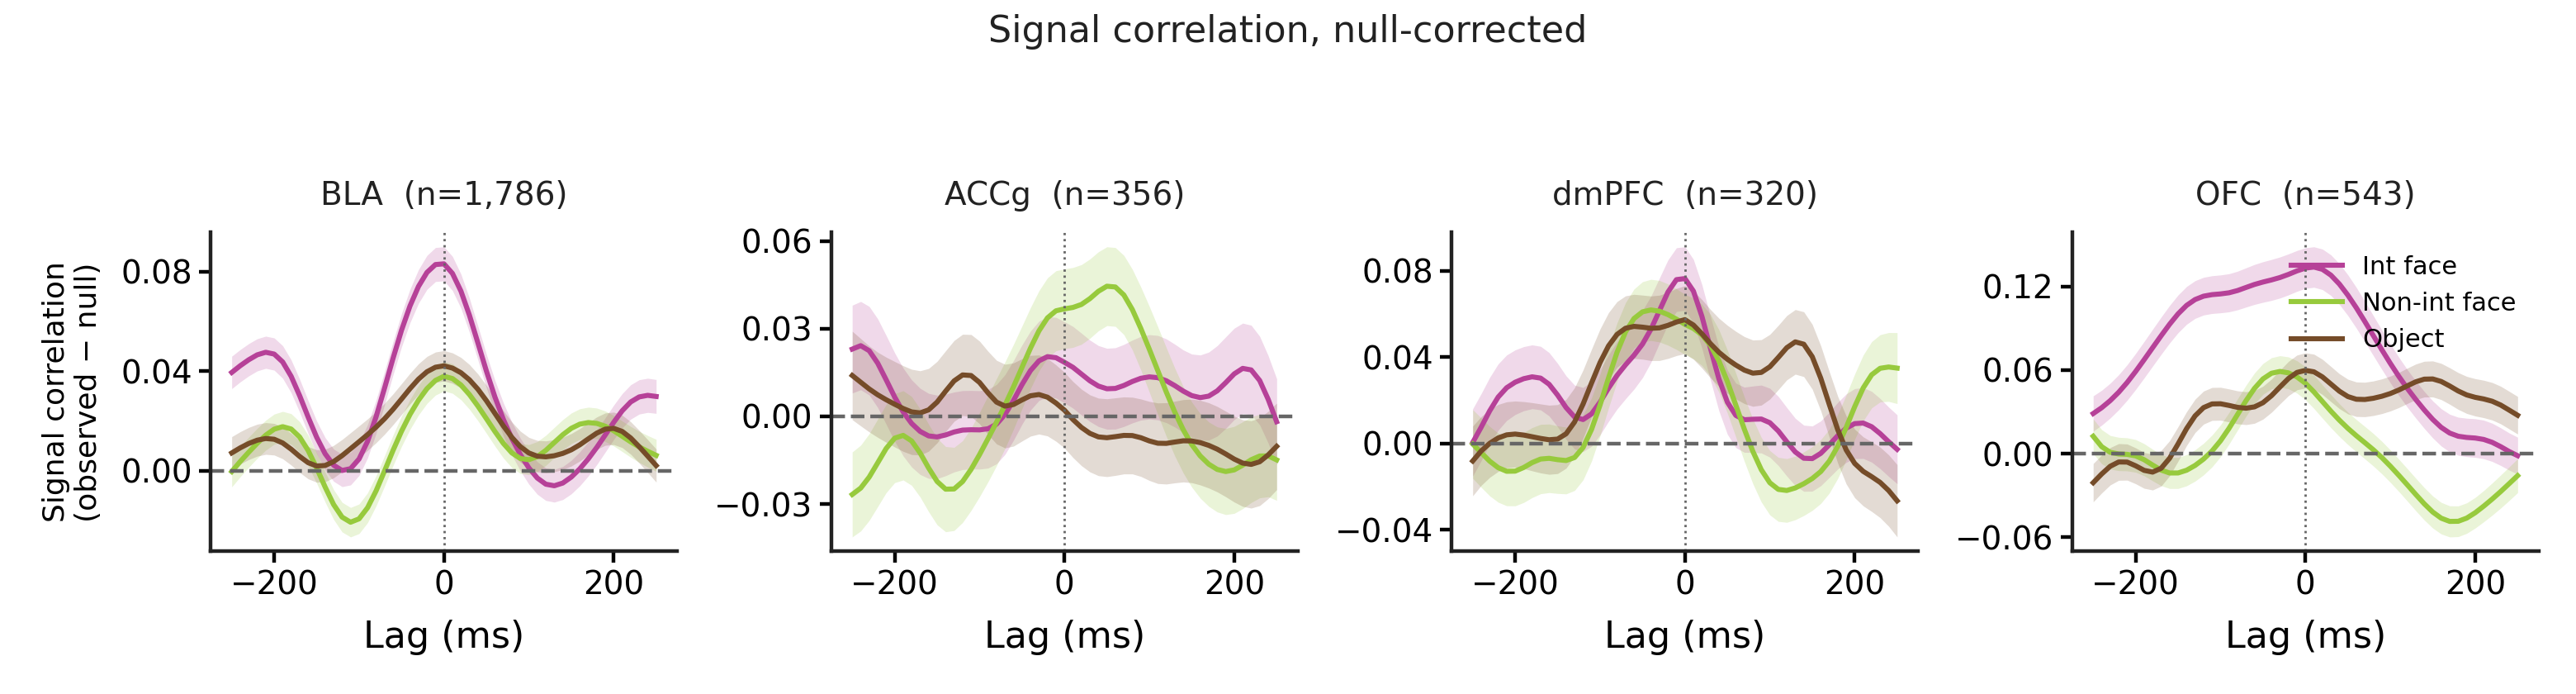

In [5]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="within_region", max_lag_ms=250.0,
    ylabel="Signal correlation\n(observed − null)",
    title="Signal correlation, null-corrected",
    stem="fig03_signal_excess",
)
display(Image(filename=str(paths["png"])))

#### Figure 4 — Per-trial spike correlation against its null

Rows are fixation conditions, columns are regions. The gap between the two
curves is the coordination; the observed curve alone is not, since an
unnormalised cross-correlation scales with the product of the two firing rates.
Every panel shows a clear gap, and the accompanying test is a one-sample
Wilcoxon of each pair's ±250 ms excess against zero.

The three rows look alike. Whether they *are* alike is the next figure's
question — three near-identical pairs of curves in adjacent panels is not a
comparison a reader can make by eye.

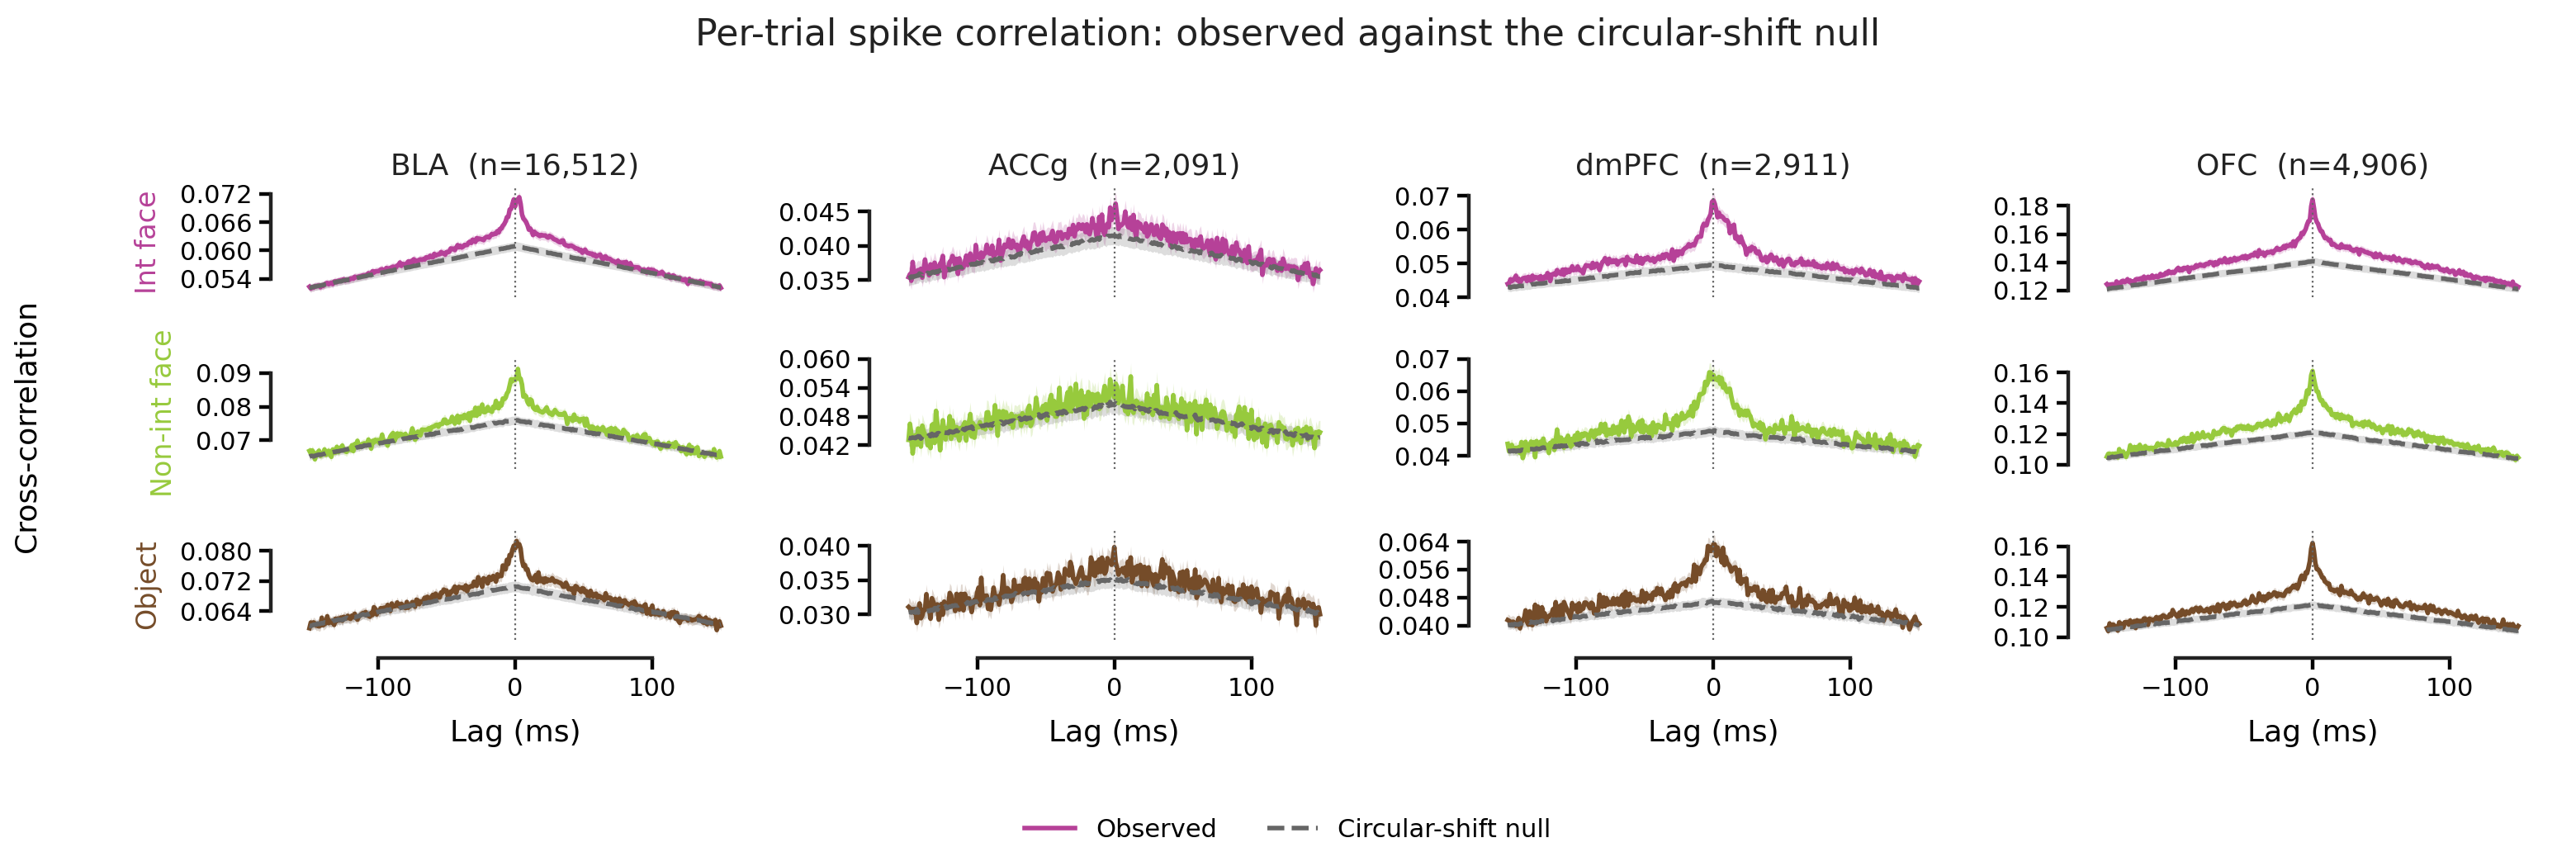

,region_pair,condition,n_pairs,mean_excess,p_value
0,accg,face_interactive,2091,0.000778,2.371621e-40
1,accg,face_non_interactive,1394,0.000552,8.246894e-08
2,accg,object,1841,0.000603,2.619421e-23
3,bla,face_interactive,16512,0.000938,0.000000e+00
4,bla,face_non_interactive,10352,0.001295,1.447779e-136
5,bla,object,12151,0.000927,7.900848e-105
6,dmpfc,face_interactive,2911,0.002805,1.676758e-155
7,dmpfc,face_non_interactive,2135,0.002005,1.217832e-52
8,dmpfc,object,2008,0.002329,2.711200e-55
9,ofc,face_interactive,4906,0.005524,1.496743e-263


In [6]:
fig, paths = viz.plot_spike_correlation_above_null(
    spike_traces, figs, scope="within_region", stem="fig04_spike_above_null"
)
display(Image(filename=str(paths["png"])))

display(
    psc.test_against_null(
        spikes.loc[spikes["scope"] == "within_region"], metric=psc.WINDOW_METRIC,
        group_columns=("region_pair", "condition"),
    ).loc[:, ["region_pair", "condition", "n_pairs", "mean_excess", "p_value"]]
)

#### Figure 5 — Per-trial spike correlation by fixation type

Each curve above, reduced to its mean over ±250 ms minus the null's, on the
trial-count-matched recomputation. Bars are marked only where the paired
contrast survives FDR.

Interactive face is highest in dmPFC and OFC and both contrasts survive
correction, but the rank-biserial effect sizes are 0.037–0.073 — a population
split near 53% to 47%, against effect sizes on signal correlation that reach 0.30
in OFC. BLA runs the other way, with non-interactive face nominally highest;
that is also the one BLA contrast that does not survive correction, so it is an
absence of difference rather than a reversal.

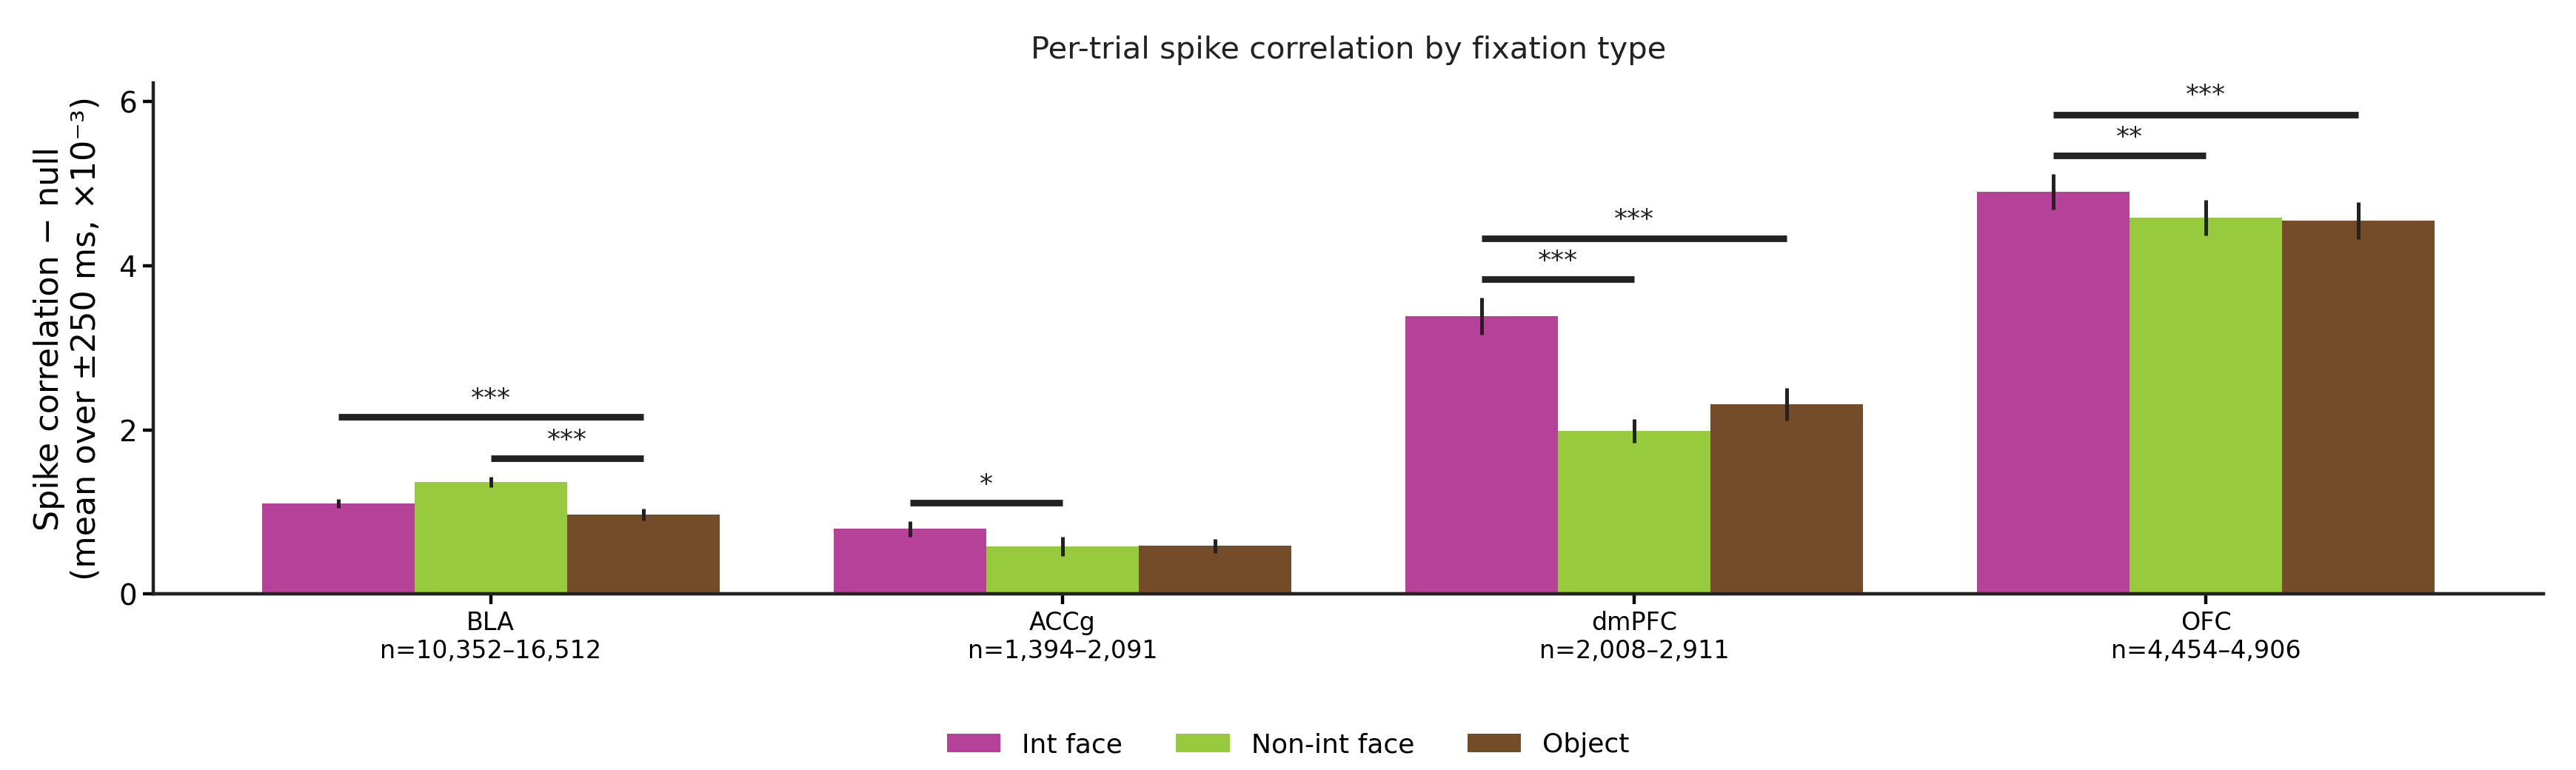

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.794,0.582,0.586
bla,1.107,1.364,0.967
dmpfc,3.385,1.990,2.312
ofc,4.900,4.588,4.550


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
12,accg,face_interactive,face_non_interactive,1356,0.00032,0.06421,0.04525,True
13,accg,face_interactive,object,1521,0.00027,0.01907,0.21468,False
14,accg,face_non_interactive,object,1323,-0.00001,0.00227,0.87698,False
15,bla,face_interactive,face_non_interactive,9391,0.00006,0.00373,0.79273,False
16,bla,face_interactive,object,10012,0.00038,0.03712,0.00000,True
17,bla,face_non_interactive,object,8479,0.00038,0.03952,0.00003,True
18,dmpfc,face_interactive,face_non_interactive,1906,0.00168,0.07312,0.00005,True
19,dmpfc,face_interactive,object,1813,0.00195,0.07182,0.00000,True
20,dmpfc,face_non_interactive,object,1609,-0.00027,-0.00933,0.71767,False
21,ofc,face_interactive,face_non_interactive,4288,0.00062,0.03685,0.00858,True


In [7]:
spike_summary = psc.summarize_coordination(
    spikes, metric=SPIKE_METRIC, group_columns=("scope", "region_pair", "condition")
)
spike_contrasts = psc.compare_conditions(
    spikes, metric=SPIKE_METRIC, group_columns=("scope", "region_pair")
)

fig, paths = viz.plot_spike_correlation_bars(
    spike_summary, spike_contrasts, figs, scope="within_region", stem="fig05_spike_bars"
)
display(Image(filename=str(paths["png"])))

display(
    spike_summary.loc[spike_summary["scope"] == "within_region"]
    .pivot_table(index="region_pair", columns="condition", values="mean")
    .mul(1e3).round(3)
)
display(
    spike_contrasts.loc[
        spike_contrasts["scope"] == "within_region",
        ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
         "effect_size_rank_biserial", "p_value_corrected", "significant"],
    ].round(5)
)

#### Figure 6 — Signal correlation, and how the two measures relate

Left: the same reduction applied to signal correlation. The OFC contrasts are
the largest in the chapter on either measure. Right: the Spearman correlation
across pairs between a pair's signal correlation and its per-trial spike
correlation, per region and condition — both summarised over the same ±250 ms, so
the two quantities being ranked are matched in construction. Strongly positive in
OFC interactive face (ρ = 0.54), positive throughout BLA, absent in ACCg, and
negative though not significant in dmPFC interactive face. This is a property of
particular circuits and conditions, not a general law.

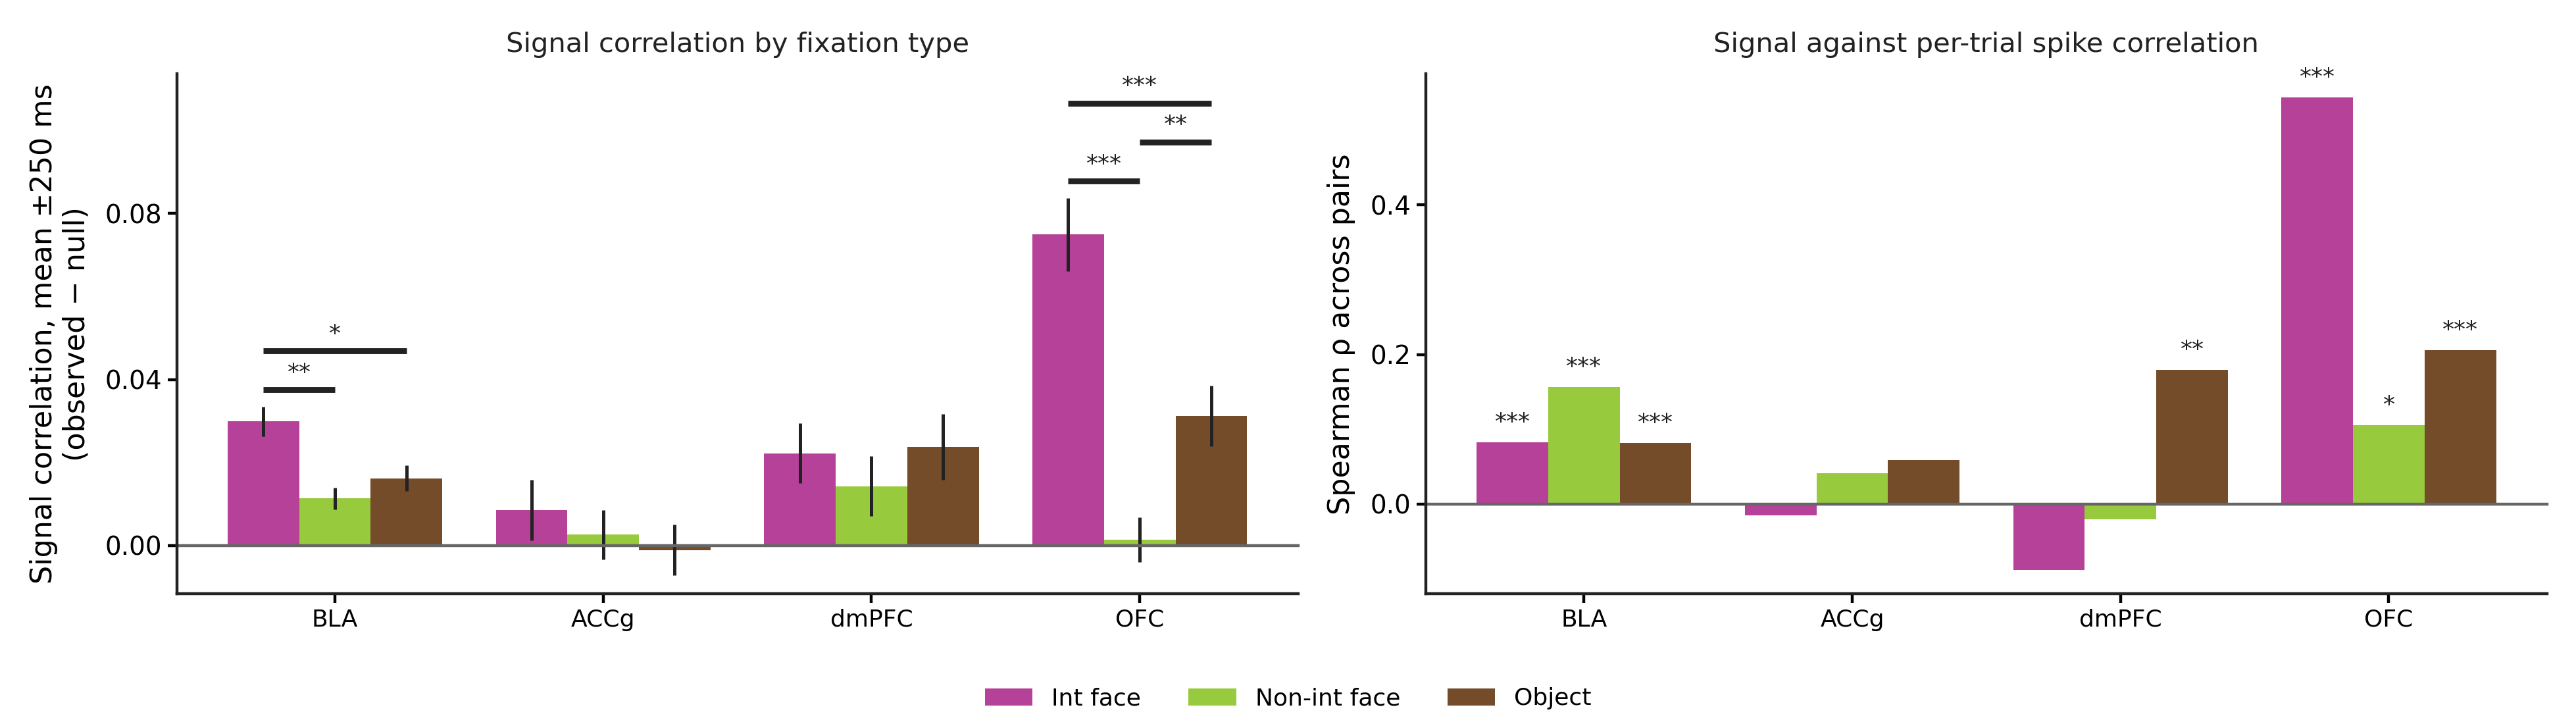

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.0085,0.0026,-0.0011
bla,0.0299,0.0113,0.0162
dmpfc,0.0222,0.0143,0.0238
ofc,0.0749,0.0014,0.0312


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg,face_interactive,face_non_interactive,356,0.0059,-0.0112,0.9462,False
1,accg,face_interactive,object,356,0.0096,0.0169,0.9130,False
2,accg,face_non_interactive,object,356,0.0037,0.0506,0.9130,False
3,bla,face_interactive,face_non_interactive,1786,0.0186,0.0705,0.0029,True
4,bla,face_interactive,object,1786,0.0137,0.0448,0.0108,True
5,bla,face_non_interactive,object,1786,-0.0049,0.0034,0.9130,False
6,dmpfc,face_interactive,face_non_interactive,320,0.0079,0.0125,0.9130,False
7,dmpfc,face_interactive,object,320,-0.0016,0.0125,0.9130,False
8,dmpfc,face_non_interactive,object,320,-0.0095,-0.0500,0.9130,False
9,ofc,face_interactive,face_non_interactive,543,0.0735,0.2965,0.0000,True


,region_pair,condition,n_pairs,spearman_rho,p_value
9,accg,face_interactive,276,-0.0147,0.8073
10,accg,face_non_interactive,248,0.0412,0.5188
11,accg,object,273,0.0587,0.3339
12,bla,face_interactive,1714,0.0828,0.0006
13,bla,face_non_interactive,1656,0.1569,0.0000
14,bla,object,1617,0.0820,0.0010
15,dmpfc,face_interactive,320,-0.0884,0.1145
16,dmpfc,face_non_interactive,318,-0.0203,0.7179
17,dmpfc,object,314,0.1797,0.0014
18,ofc,face_interactive,527,0.5436,0.0000


In [8]:
summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)
contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)
rho = correlations.loc[correlations["scope"] == "within_region"]

fig, paths = viz.plot_summary_bars(summary, contrasts, rho, figs, scope="within_region",
                                   stem="fig06_summary_bars")
display(Image(filename=str(paths["png"])))

display(
    summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)
display(
    contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)
display(rho.loc[:, ["region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]].round(4))

### Across regions

A cross-region pair exists only where both regions were recorded in the same
session, which was not true uniformly. Only BLA × ACCg, BLA × dmPFC and BLA × OFC
are populated enough to report: ACCg and OFC were never recorded together, and
dmPFC × OFC comes from a handful of sessions.

#### Figure 7 — Signal correlation

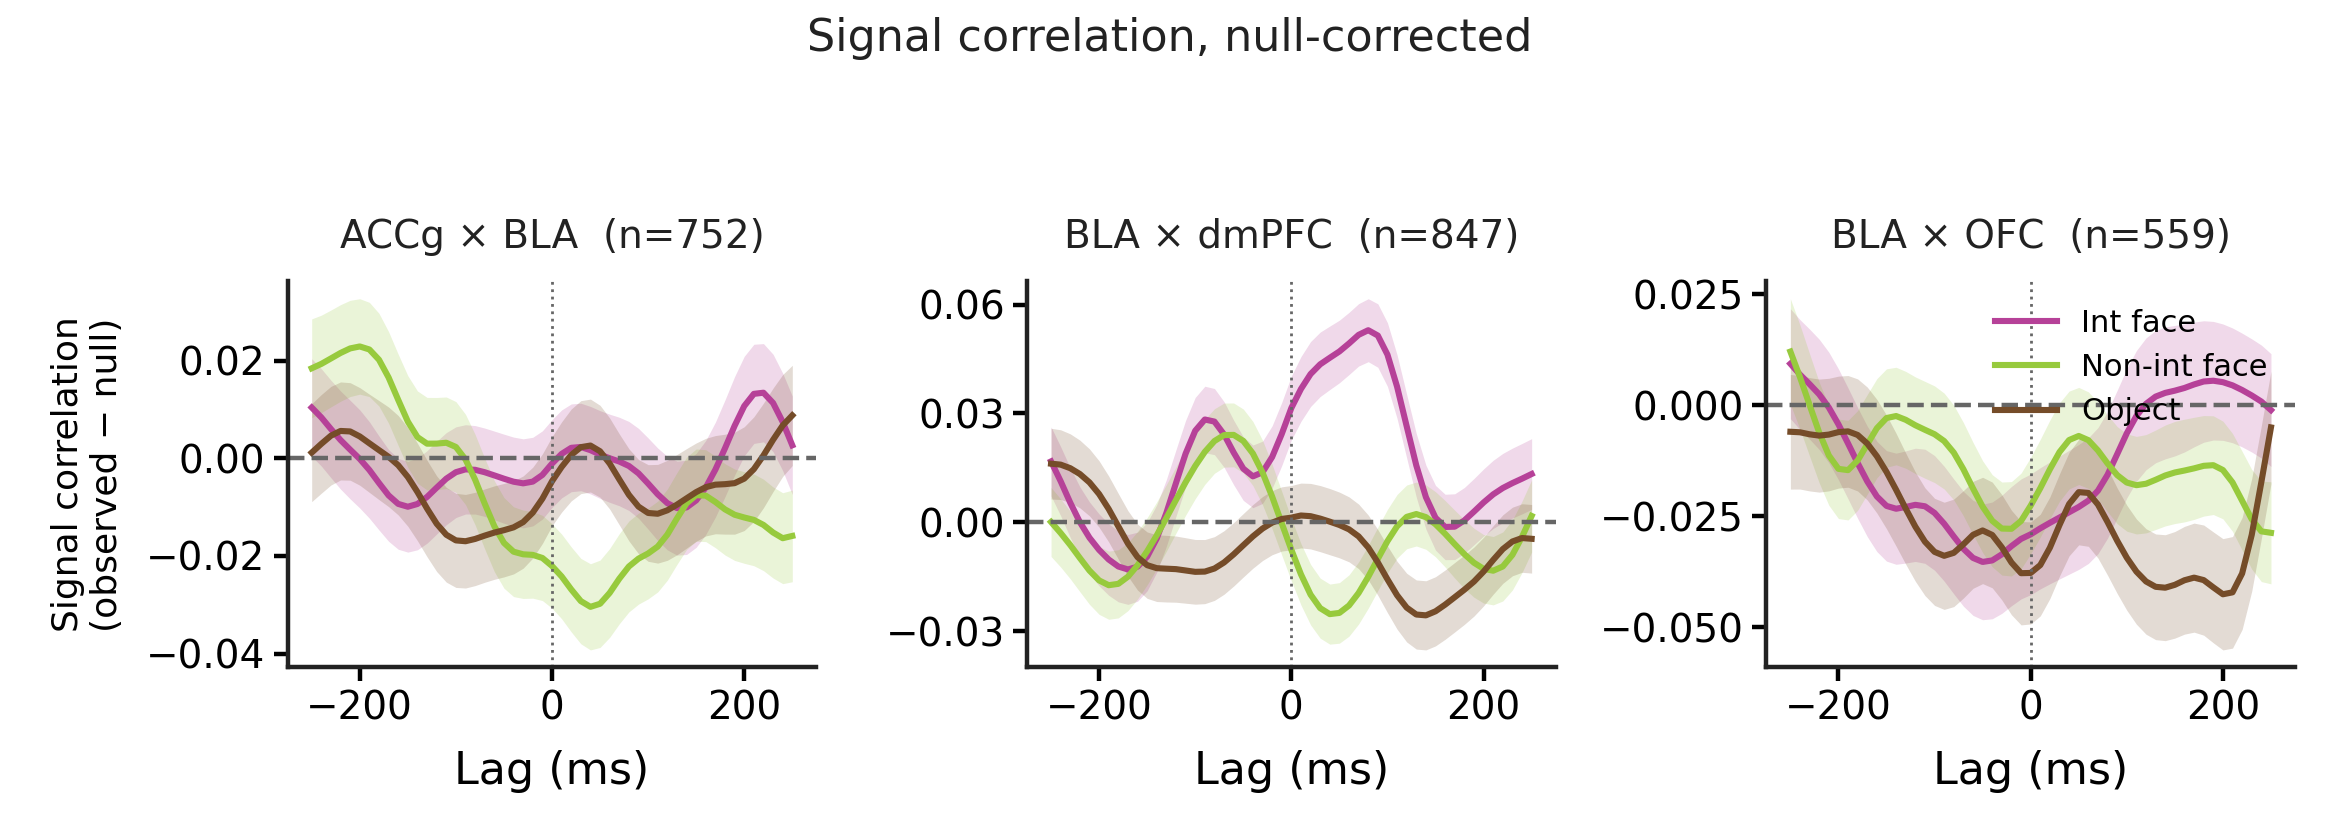

In [9]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="cross_region", max_lag_ms=250.0,
    ylabel="Signal correlation\n(observed − null)",
    title="Signal correlation, null-corrected",
    stem="fig07_signal_excess",
)
display(Image(filename=str(paths["png"])))

#### Figure 8 — Per-trial spike correlation against its null

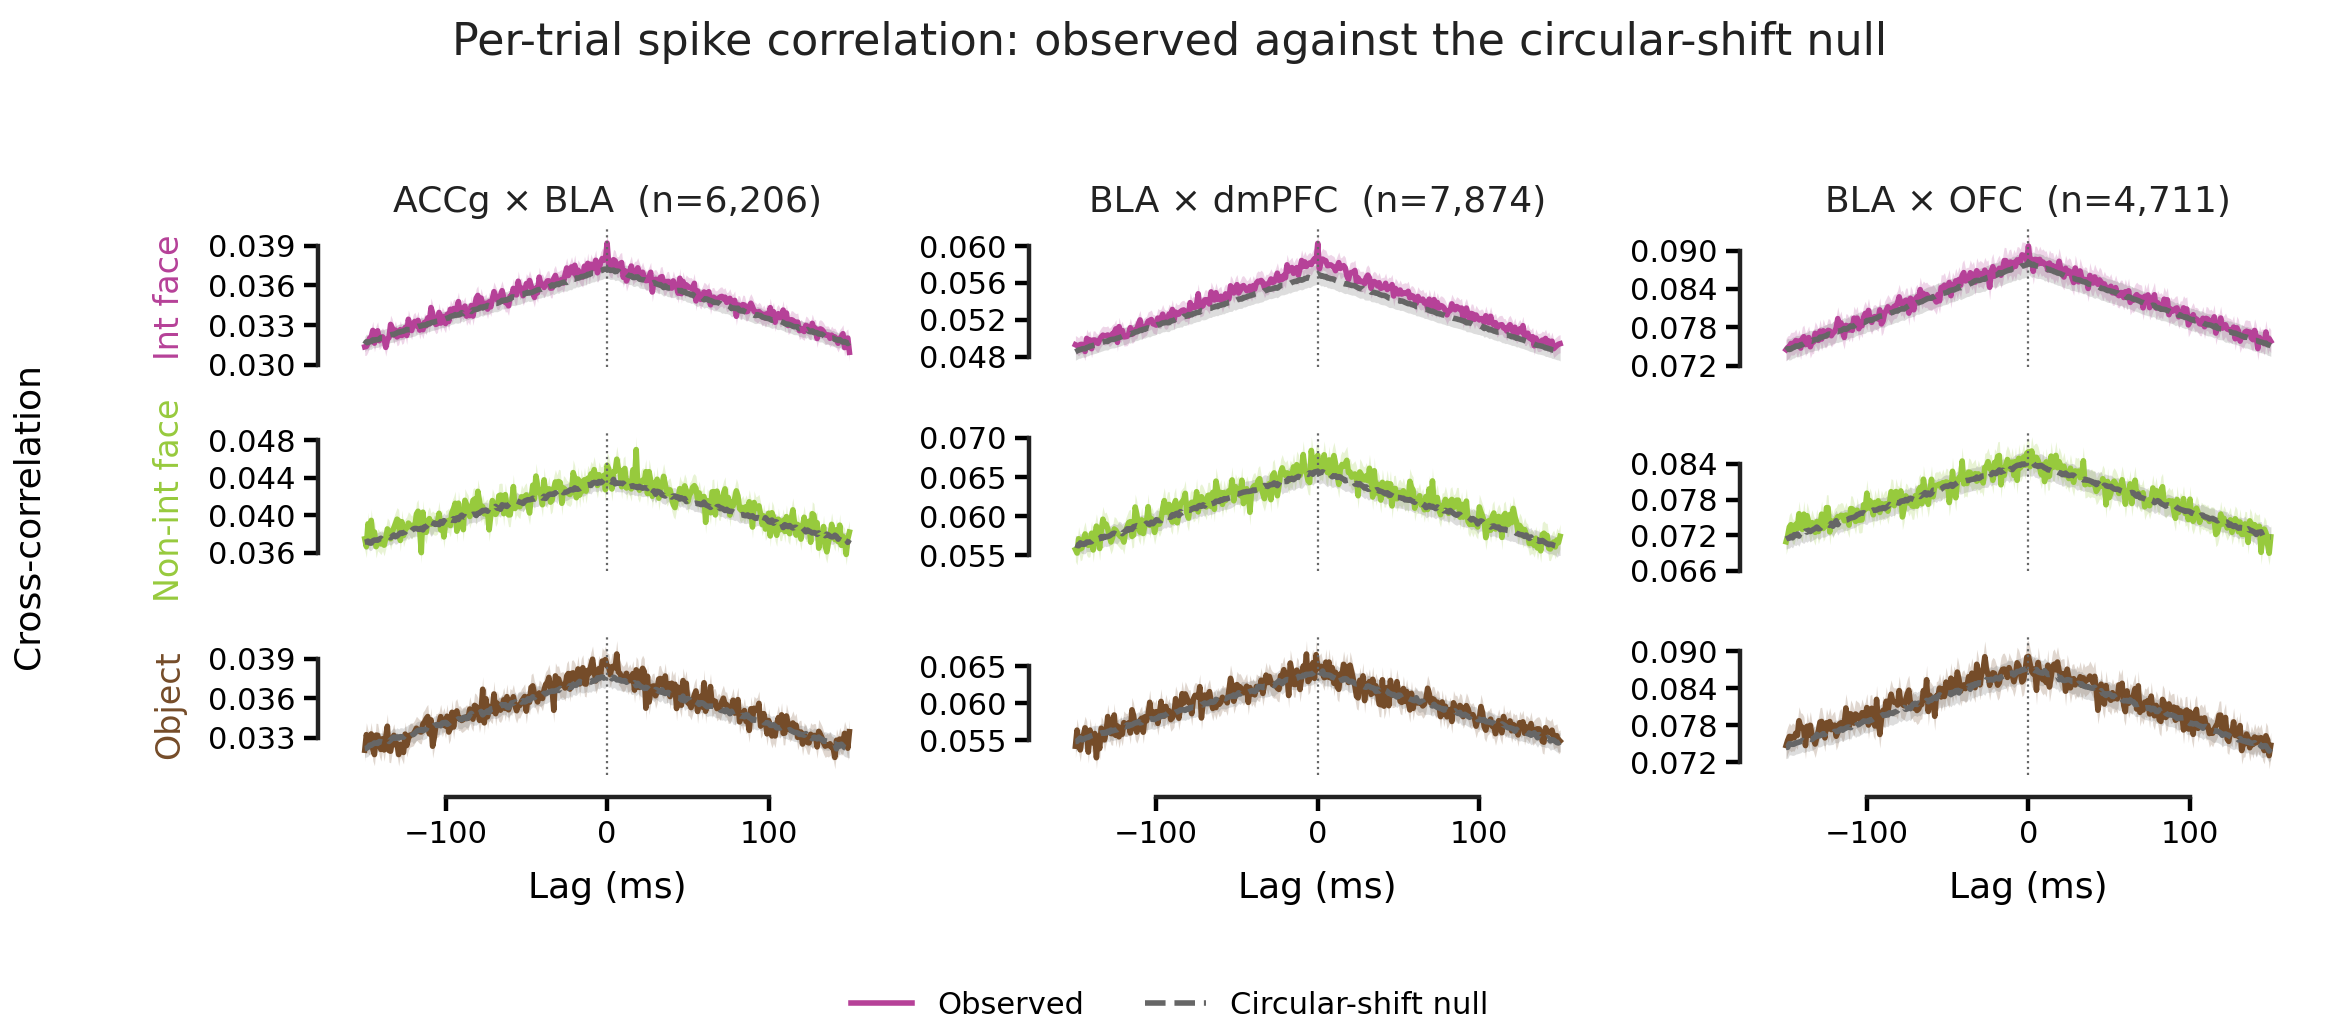

,region_pair,condition,n_pairs,mean_excess,p_value
0,accg-bla,face_interactive,6206,0.000172,2.141814e-10
1,accg-bla,face_non_interactive,4049,0.000319,7.291089e-06
2,accg-bla,object,5152,0.000126,3.649937e-04
3,accg-dmpfc,face_interactive,324,0.000140,4.933008e-04
4,accg-dmpfc,face_non_interactive,178,0.000379,3.764479e-02
5,accg-dmpfc,object,228,0.000170,2.878701e-02
6,bla-dmpfc,face_interactive,7874,0.000587,1.028523e-72
7,bla-dmpfc,face_non_interactive,5568,0.000339,3.692249e-06
8,bla-dmpfc,object,5867,0.000138,2.115177e-04
9,bla-ofc,face_interactive,4711,0.000369,2.271435e-07


In [10]:
fig, paths = viz.plot_spike_correlation_above_null(
    spike_traces, figs, scope="cross_region", stem="fig08_spike_above_null"
)
display(Image(filename=str(paths["png"])))

display(
    psc.test_against_null(
        spikes.loc[spikes["scope"] == "cross_region"], metric=psc.WINDOW_METRIC,
        group_columns=("region_pair", "condition"),
    ).loc[:, ["region_pair", "condition", "n_pairs", "mean_excess", "p_value"]]
)

#### Figure 9 — Per-trial spike correlation by fixation type

Note the axis: cross-region values are an order of magnitude below the
within-region ones (0.15–0.73 against 0.6–4.9 $\times 10^{-3}$). Only BLA × dmPFC
separates the conditions, with interactive face above both others — the same
combination, and the same direction, as in cross-region signal correlation.

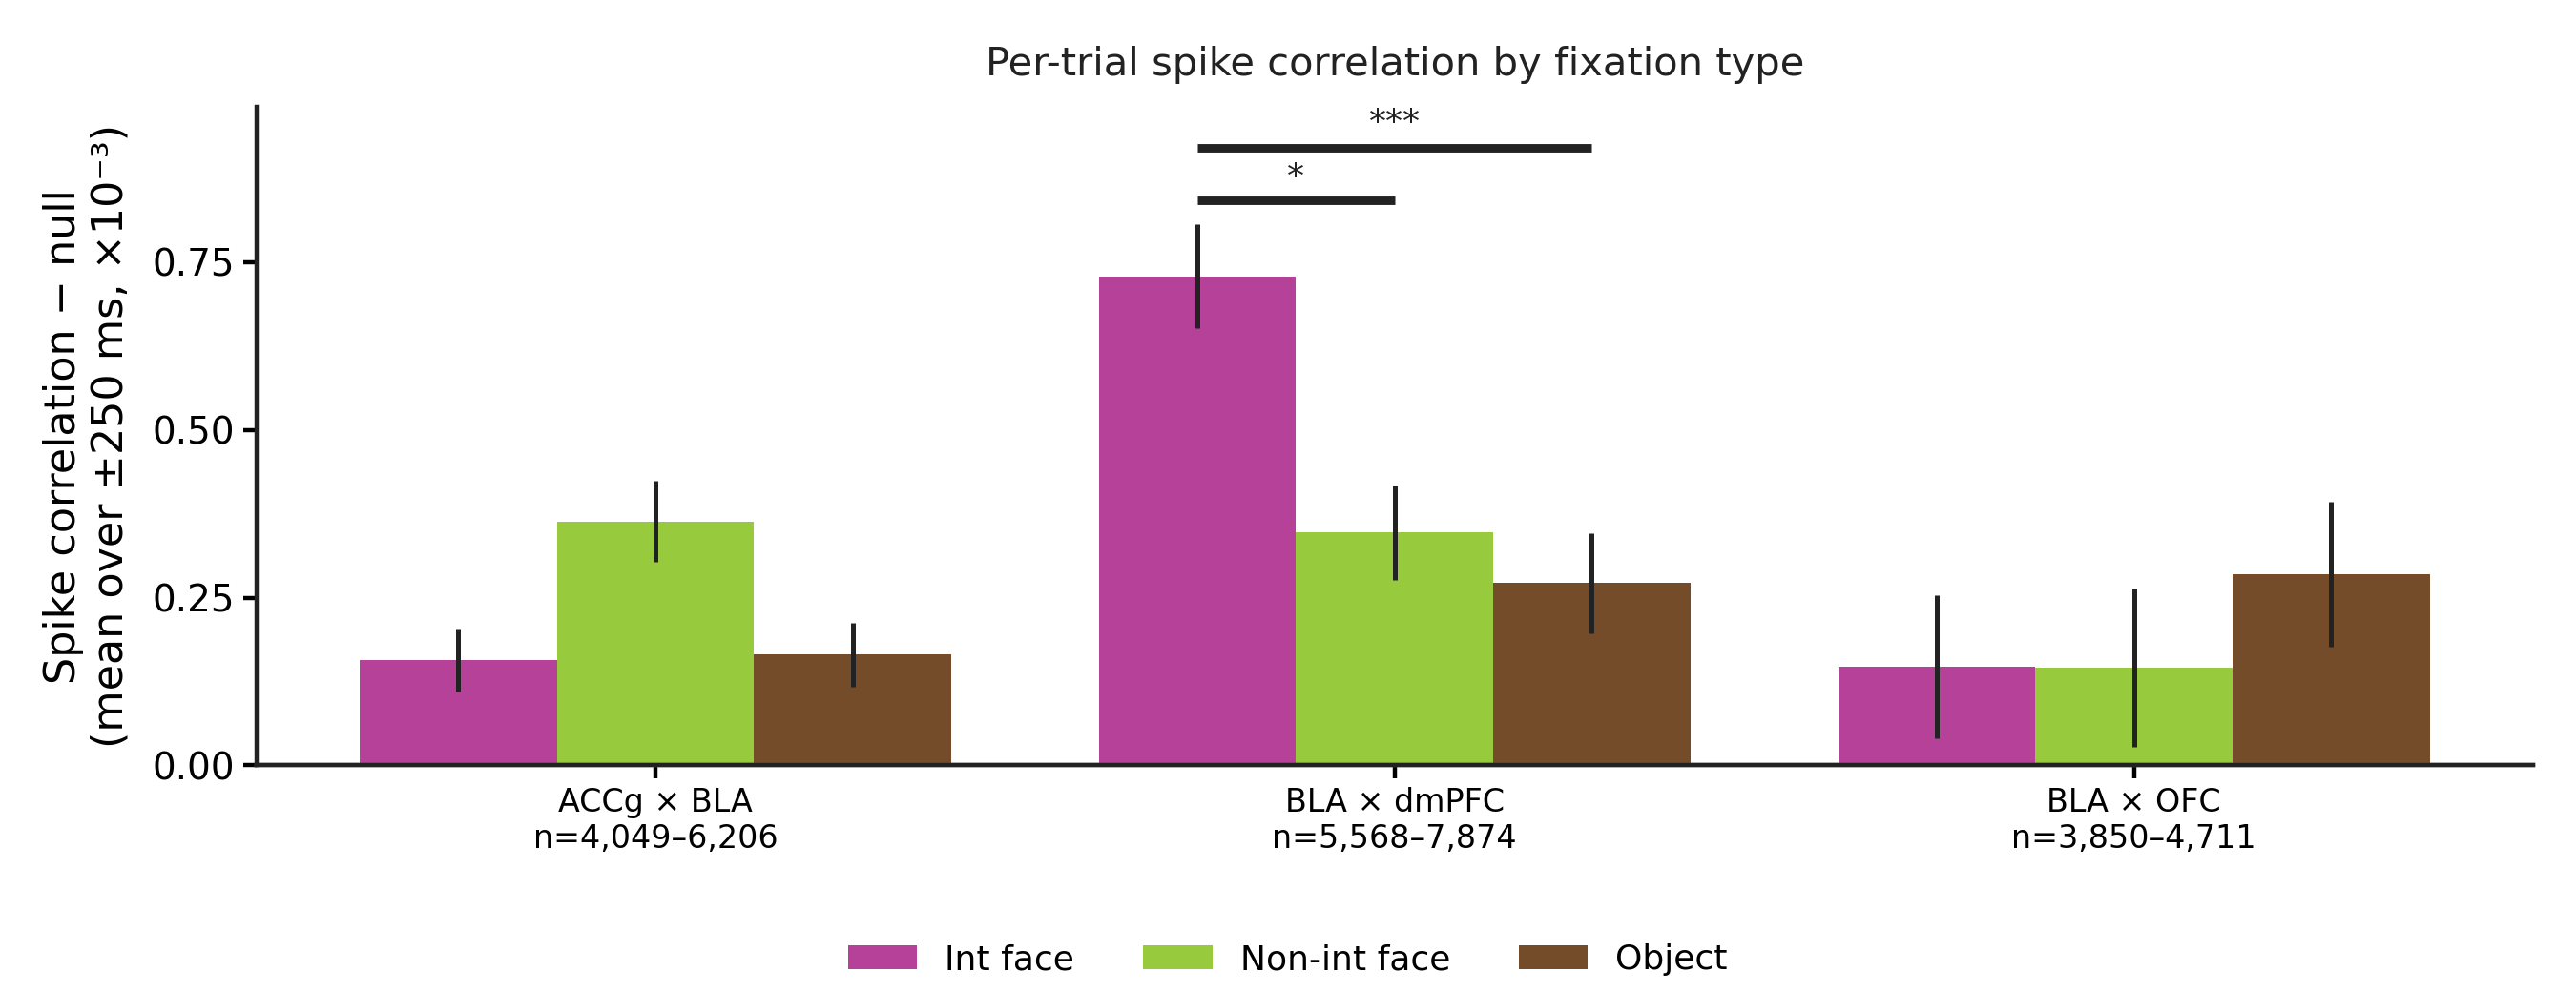

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg-bla,0.157,0.363,0.165
accg-dmpfc,0.111,0.363,0.160
bla-dmpfc,0.729,0.347,0.271
bla-ofc,0.147,0.146,0.285


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg-bla,face_interactive,face_non_interactive,3773,-0.00019,-0.00928,0.19639,False
1,accg-bla,face_interactive,object,4044,0.00003,0.00272,0.98210,False
2,accg-bla,face_non_interactive,object,3568,0.00021,0.02130,0.11155,False
3,accg-dmpfc,face_interactive,face_non_interactive,163,-0.00019,-0.01840,0.88820,False
4,accg-dmpfc,face_interactive,object,163,0.00004,0.03067,0.92746,False
5,accg-dmpfc,face_non_interactive,object,135,0.00019,-0.05185,0.88820,False
6,bla-dmpfc,face_interactive,face_non_interactive,5018,0.00036,0.03708,0.02255,True
7,bla-dmpfc,face_interactive,object,5191,0.00061,0.04180,0.00035,True
8,bla-dmpfc,face_non_interactive,object,4584,0.00009,-0.01178,0.99733,False
9,bla-ofc,face_interactive,face_non_interactive,3684,0.00004,-0.00081,0.86706,False


In [11]:
spike_summary = psc.summarize_coordination(
    spikes, metric=SPIKE_METRIC, group_columns=("scope", "region_pair", "condition")
)
spike_contrasts = psc.compare_conditions(
    spikes, metric=SPIKE_METRIC, group_columns=("scope", "region_pair")
)

fig, paths = viz.plot_spike_correlation_bars(
    spike_summary, spike_contrasts, figs, scope="cross_region", stem="fig09_spike_bars"
)
display(Image(filename=str(paths["png"])))

display(
    spike_summary.loc[spike_summary["scope"] == "cross_region"]
    .pivot_table(index="region_pair", columns="condition", values="mean")
    .mul(1e3).round(3)
)
display(
    spike_contrasts.loc[
        spike_contrasts["scope"] == "cross_region",
        ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
         "effect_size_rank_biserial", "p_value_corrected", "significant"],
    ].round(5)
)

#### Figure 10 — Signal correlation, and how the two measures relate

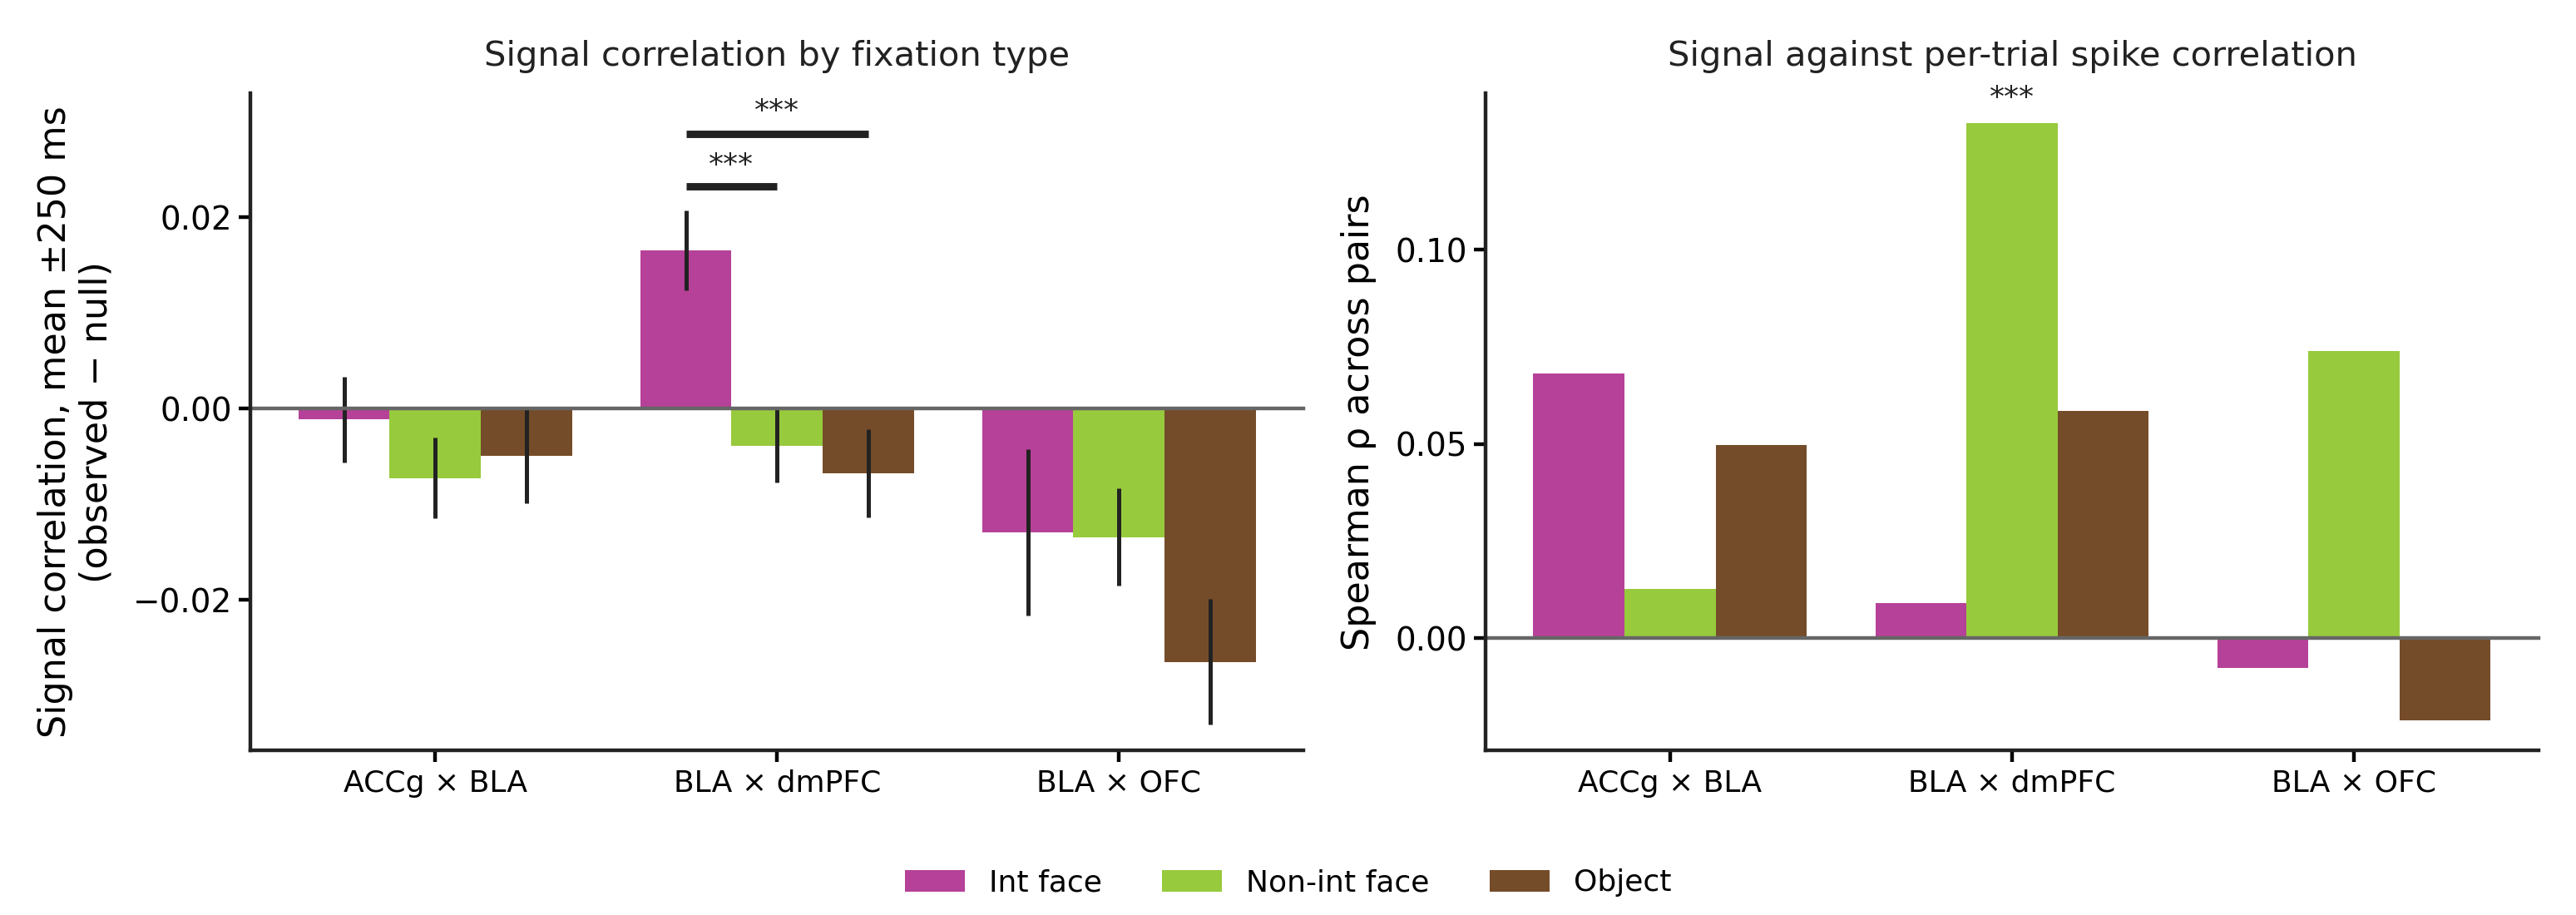

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg-bla,-0.0011,-0.0072,-0.0050
bla-dmpfc,0.0166,-0.0039,-0.0068
bla-ofc,-0.0129,-0.0134,-0.0265


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg-bla,face_interactive,face_non_interactive,752,0.0061,0.0452,0.5120,False
1,accg-bla,face_interactive,object,752,0.0038,0.0532,0.6749,False
2,accg-bla,face_non_interactive,object,752,-0.0023,-0.0293,0.7487,False
3,bla-dmpfc,face_interactive,face_non_interactive,847,0.0205,0.1334,0.0002,True
4,bla-dmpfc,face_interactive,object,847,0.0233,0.1405,0.0002,True
5,bla-dmpfc,face_non_interactive,object,847,0.0029,-0.0106,0.7487,False
6,bla-ofc,face_interactive,face_non_interactive,559,0.0005,-0.0125,0.9056,False
7,bla-ofc,face_interactive,object,559,0.0136,0.0161,0.6749,False
8,bla-ofc,face_non_interactive,object,559,0.0131,0.0304,0.5120,False


,region_pair,condition,n_pairs,spearman_rho,p_value
0,accg-bla,face_interactive,734,0.0682,0.0647
1,accg-bla,face_non_interactive,709,0.0128,0.7342
2,accg-bla,object,713,0.0498,0.1840
3,bla-dmpfc,face_interactive,847,0.0090,0.7937
4,bla-dmpfc,face_non_interactive,814,0.1325,0.0001
5,bla-dmpfc,object,810,0.0585,0.0960
6,bla-ofc,face_interactive,505,-0.0076,0.8652
7,bla-ofc,face_non_interactive,490,0.0740,0.1020
8,bla-ofc,object,491,-0.0212,0.6386


In [12]:
summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)
contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)
rho = correlations.loc[correlations["scope"] == "cross_region"]

fig, paths = viz.plot_summary_bars(summary, contrasts, rho, figs, scope="cross_region",
                                   stem="fig10_summary_bars")
display(Image(filename=str(paths["png"])))

display(
    summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)
display(
    contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)
display(rho.loc[:, ["region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]].round(4))

## Discussion

### The fixation-condition effect is in shared tuning, not co-firing

The clearest result is a dissociation. Signal correlation differs between
fixation conditions — interactive face is higher than both other conditions in
BLA ($r_{\text{rb}} = 0.045$ and $0.071$) and, far more strongly, in OFC
($0.19$ and $0.30$), and these survive correction. Per-trial spike correlation is
modulated far more weakly:
the largest within-region effect size is **0.073** (dmPFC, interactive face
against non-interactive) and most sit below 0.05, so a "significant" contrast
there describes a population split of roughly 52% to 48%.

The two measures are computed from the same spike trains, on the same pairs, in
the same window, against equally conservative nulls. The difference between them
is one step — whether trials are averaged before or after correlating. That the
condition effect is large on one side of that step and marginal on the other is
informative: what interactive fixation changes is mostly **how much two neurons'
average responses resemble each other**, and only marginally how tightly they
co-fire within a fixation.

Framed in population terms, this is a change in the *representation* rather than
in the *correlation structure*. It is the less common of the two findings in this
literature, where attention and state effects are usually reported on noise
correlation.

The qualification matters, though, and the bar figures are where it shows. The
per-trial effect is not zero. In dmPFC and OFC interactive face is above both
other conditions with $r_{\text{rb}}$ between 0.04 and 0.07, and it holds after
trial-count matching, so it is not an artifact of interactive fixations being
more numerous.
The honest statement is a difference of degree: both measures move in the same
direction, and signal correlation moves several times further.

### Both forms of coupling exist, and are regionally organised

Neither result is a null. Per-trial spike correlation sits clearly above the
circular-shift null in every region and condition — a null that already preserves
each fixation's spike count and slow envelope, and so credits nothing to shared
excitability. Signal correlation sits clearly above a null built from real,
fixation-locked units of the same region.

The magnitudes are ordered the same way on both measures. OFC and dmPFC carry the
largest per-trial excess (≈ 4.7 and ≈ 2.6 $\times 10^{-3}$), BLA and ACCg the
smallest (≈ 1.1 and ≈ 0.65 $\times 10^{-3}$), and OFC also has the largest signal
correlation and by far the largest condition effect on it. ACCg is the weakest on
both and is the only region where no signal-correlation contrast survives
correction at all. The one place the conditions invert is BLA's per-trial
measure, where non-interactive face is nominally highest — and that is also the
one BLA contrast that does not survive correction, so it is better read as an
absence of difference than as a reversal.

### The effect is a population shift, not a coupled subpopulation

The inventory figure carries a result that is easy to skip past. The *population*
of pairs sits above its null with p-values indistinguishable from zero — down to
$10^{-263}$ in OFC — but at most **1.9%** of *individual* pairs survives FDR
correction across pairs (dmPFC and OFC interactive face), it is under 0.5% in
BLA, it is **zero** in ACCg, and across regions it is 4 pairs out of 33,000. There is no subset of strongly coupled
pairs driving the average; there is a small, broadly distributed shift in a large
population. Any claim phrased in terms of "coordinated pairs" would be describing
one or two percent of the data.

### Shared tuning and co-firing are related, but only within a region

Pairs with more shared tuning also co-fire more, within region: OFC interactive
face reaches ρ = 0.54, dmPFC object ρ = 0.18, and all three BLA conditions are
positive with non-interactive face highest at ρ = 0.16. This is not automatic — the two quantities come from different operations and either
can exist without the other — so a positive relationship says the same local
circuitry plausibly produces both. It does not hold everywhere: no ACCg combination reaches
significance, and dmPFC's interactive-face correlation is negative (ρ = −0.09,
n.s.) while its object correlation is the region's strongest. The relationship is
a feature of particular circuits and conditions rather than a general law.

Across regions the relationship is all but absent — one of nine combinations
reaches significance (BLA × dmPFC, non-interactive face, ρ = 0.13) — and so is
most of the coupling.
Cross-region per-trial excess is an order of magnitude below within-region
(≈ 0.15–0.7 $\times 10^{-3}$ against 0.6–5), and cross-region signal correlation is
at or below zero for most combinations. The one exception is **BLA × dmPFC during
interactive face**, which stands above both other conditions on *both* measures —
$r_{\text{rb}} = 0.13$ and $0.14$ on signal correlation, $0.037$ and $0.042$ on
the per-trial measure — and is the only cross-region signal correlation anywhere
in the chapter that is positive rather than at or below its null. That it
involves BLA and dmPFC specifically is worth following up rather than treating as
noise, but it is one comparison among nine and should be replicated before it
carries weight.

### Limitations

**Trial-count imbalance is the main threat to the signal-correlation result.**
Interactive-face fixations outnumber the others roughly six to one, so
interactive-face mean timelines are estimated more precisely and correlate better
with anything. The cross-session null does not absorb this: the null partner
shares no tuning, so its correlation sits near zero whatever the precision. The
per-trial contrasts are trial-count matched and do not carry the problem; the
signal contrasts cannot be, because no matched average exists. Stratifying by the
interactive-to-object trial ratio bounds it directly, and in the lowest stratum
the advantage is near zero — so the reported signal-correlation sizes should be
treated as **upper bounds**. A definitive test requires re-averaging the per-trial
PSTHs at matched trial counts.

**Spearman's correction for attenuation is unavailable here.** It would be the
textbook remedy for comparing correlations between differently reliable
estimates, but it needs each timeline's reliability, and these means are smoothed
before averaging while the SEMs are not correspondingly reduced, so the estimate
comes out negative for most units. The estimator is retained as a diagnostic that
reports its own failure rather than silently producing a number.

**Cross-region coverage is set by the recordings, not by choice.** Every
well-populated cross-region combination involves BLA; ACCg and OFC were never
recorded simultaneously, and dmPFC × OFC comes from a handful of sessions. The
absence of a cross-region effect is therefore a statement about BLA–frontal
pairs, not about cortico-cortical coupling in general.

**Pair counts are not independent observations.** A session with 20 simultaneous
units contributes 190 pairs sharing 20 units, so the effective sample size is
well below the pair count and the p-values are correspondingly optimistic. This
is why effect sizes carry the argument here, and why the pairing structure — the
same pair in all three conditions — is doing the real work: it makes each
contrast a within-pair comparison, immune to how many pairs a session supplied.

**Selective units only.** Restricting to selective units makes the question well
posed but means these results describe the responsive subpopulation. Whether
non-selective pairs show the same architecture is untested here.

**Simultaneity is required by the per-trial measure but not the signal measure.**
Signal correlation is computed on simultaneously recorded pairs so the two can be
compared pair for pair, but it could in principle be computed across sessions —
indeed that is what the null does. The restriction costs statistical power on the
signal side and should be relaxed if signal correlation is ever the sole question.

### Conclusion

Simultaneously recorded pairs of selective neurons in BLA, ACCg, dmPFC and OFC
show both shared tuning and within-fixation co-firing, each above a conservative
null, and both are a broadly distributed property of the population rather than
the signature of a coupled minority. Interactive-face fixation modulates shared
tuning substantially and co-firing only marginally, most strongly in OFC and
dmPFC, and the two forms of coupling are related within a region but not across
regions. What social interaction changes in these circuits, on this evidence, is
mostly what pairs of neurons jointly represent — rather than how tightly they
fire together while representing it.